# Estrategias de Trading con Análisis Técnico — Lab 02

**Microestructuras y Sistemas de Trading (IT1731B) · ITESO, Otoño 2026 · Equipo 3 · Nivel C**

Gonzalo Cano Padilla · Juan Manuel Espinosa Cárdenas · Jerónimo Rojas Alvarado · Raúl Zanatta Casas

---

## Resumen

Diseñamos una estrategia direccional larga y corta sobre 8 activos de EE.UU. con barras diarias. Se
abre posición solo si al menos 2 de 3 indicadores técnicos coinciden. El capital se reparte con
Risk Parity, escalado por la fuerza de la señal y por el régimen de mercado (tendencia, reversión o
crisis). Los parámetros se optimizan con Optuna en un walk-forward de 6 meses de entrenamiento y 1
mes de prueba.

Todas las decisiones se tomaron con train (2018–2021). Validation (2022–2023) se usó una sola vez,
para decisiones discretas fijadas de antemano, y test (2024–sep 2026) se corrió una sola vez con el
código congelado. El reporte presenta los resultados tal como salieron, incluidos los negativos, y
responde las siete preguntas de la sección 4 del lab.

Este notebook es el reporte: solo carga los resultados de `python main.py` (carpeta `results/`) y
las figuras de `docs/figuras/`; no recalcula ni reoptimiza nada.

In [1]:
import os
import pickle
from pathlib import Path

# Los pickles guardan objetos de src/ (por ejemplo, BacktestResult): se trabaja desde la raíz.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import pandas as pd
from IPython.display import Image, Markdown, display

RESULTS = Path("results")
FIGURES = Path("docs") / "figuras"
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.4f}".format)

r = {path.stem: pickle.load(open(path, "rb")) for path in sorted(RESULTS.glob("*.pkl"))}
final = r["final_backtests"]
wf = r["walk_forward"]
columnas = ["ann_return", "ann_vol", "sharpe", "sortino", "calmar", "max_drawdown", "n_trades", "win_rate"]

**Corrida.** Commit del código congelado y tipo de corrida (`final_run = True` incluye test):

In [2]:
display(pd.Series(r["corrida"]))

commit                 45bedfaaa0377322fbeffa18387666ccc5b362d6
uncommitted_changes                                        True
final_run                                                  True
elapsed_seconds                                      2,320.1051
finished                                    2026-10-06 19:05:48
dtype: object

La marca `uncommitted_changes` se debe a las figuras que la propia corrida escribe en
`docs/figuras/`, que aún no estaban en git. Ningún archivo con seguimiento cambió: el código es el
del commit congelado.

## 1. Datos y universo

**Activos.** Los cuatro integrantes elegimos en conjunto los 8 activos, con criterios comunes: alta
liquidez, historia completa desde antes de 2016 y exposición a sectores distintos. No hubo un reparto
de activos por integrante.

| Ticker | Activo | Tipo | Sector |
|---|---|---|---|
| AAPL | Apple | Acción | Tecnología |
| MSFT | Microsoft | Acción | Tecnología |
| META | Meta Platforms | Acción | Tecnología |
| AMD | Advanced Micro Devices | Acción | Semiconductores |
| XOM | Exxon Mobil | Acción | Energía |
| SMH | VanEck Semiconductor ETF | ETF | Semiconductores |
| GLD | SPDR Gold Shares | ETF | Oro |
| COPX | Global X Copper Miners ETF | ETF | Cobre |

**Datos.** Barras diarias OHLCV de Yahoo Finance, ajustadas por splits y dividendos, de 2017-01-02 a
2026-09-30. 2017 solo calienta indicadores. La tasa libre de riesgo es el T-Bill de 13 semanas
(`^IRX`). La auditoría no encontró NaN, precios no positivos, incoherencias OHLC ni fechas
descartadas en la intersección de los 8 activos. Ningún hueco se rellenó.

**Concentración declarada.** Cinco de los ocho activos son tecnología o semiconductores (SMH
contiene a AMD), así que se espera correlación alta entre ellos. Risk Parity la penaliza y la
política de conflictos de señal la atiende. COPX es el menos líquido del universo.

| Bloque | Fechas | Uso |
|---|---|---|
| Train | 2018-01-01 → 2021-12-31 | Diseño de reglas, estudios de diagnóstico y calibraciones |
| Validation | 2022-01-01 → 2023-12-31 | Una corrida para decisiones discretas |
| Test | 2024-01-01 → 2026-09-30 | Una sola corrida con todo congelado |

In [3]:
display(r["datos_regimen"]["audit"])

,n_obs,start,end,nan,non_positive,high_lt_low,open_outside,close_outside,zero_volume,dropped_dates
AAPL,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
MSFT,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
META,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
AMD,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
XOM,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
SMH,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
GLD,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
COPX,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0


## 2. Estrategia

**Indicadores y votos** (x_j ∈ {−1, 0, +1}; un indicador sin datos suficientes vota 0):

| Indicador | Familia | Voto |
|---|---|---|
| Cruce de SMA (f, s) | Tendencia | x_sma = sgn(SMA_f − SMA_s) |
| Histograma MACD 12/26/9 | Momento | x_macd = sgn(MACD − señal) |
| RSI de Wilder (n, lo, hi) | Momento | +1 si 50 < RSI < hi; −1 si lo < RSI ≤ 50; 0 en otro caso |
| ATR de Wilder 14 | Volatilidad | No vota: fija el stop-loss y el take-profit |

**Regla de confirmación 2 de 3.** Con Σx = x_sma + x_macd + x_rsi:

$$
s_t = \begin{cases} \dfrac{\Sigma x}{3} & \text{si } |\Sigma x| \ge 2 \\[4pt] 0 & \text{en otro caso} \end{cases}
\qquad\qquad \text{Estado}_t = \operatorname{sgn}(s_t) \in \{-1, 0, +1\}
$$

El estado decide si hay posición. La fuerza s ∈ {±2/3, ±1} escala el capital asignado: 3 de 3 pesa
más que 2 de 3. Dos votos a favor y uno en contra (Σx = 1) no abren posición.

**Ejecución.** La señal se calcula con información hasta el cierre de t y se ejecuta al Open de
t + 1. Ese desplazamiento solo existe dentro del motor.

**Salidas.** Con ATR₀ congelado al abrir y L = ±1 el lado:

$$ SL = E - L \cdot k \cdot ATR_0 \qquad TP = E + L \cdot r \cdot k \cdot ATR_0 $$

- **Señal opuesta:** cierra al Open siguiente y abre el lado contrario.
- **Holding máximo:** después de m barras, cierra al Open siguiente.
- **Rearme:** tras un TP, el lado queda armado. Tras un SL o un holding máximo, queda desarmado hasta
  que el estado cambie.
- **Prioridades en la barra:** si SL y TP caen en la misma barra, se ejecuta primero el stop. Un gap
  más allá del SL llena al Open; un gap más allá del TP llena en el TP, sin mejora de precio.

**Asignación y tamaño.** Para cada activo:

$$ \tilde w_i = w_i^{RP} \cdot s_i \qquad w^{target} = m(\text{régimen}) \cdot \frac{\tilde w}{\max(1, \Sigma|\tilde w_i|)} \qquad C_i = |w_i^{target}| \cdot \text{Equity} $$

Cada entrada usa todo su capital asignado: acciones = C_i / (E · (1 + comisión)). Como
Σ|w^target| ≤ 1, nunca hay apalancamiento. Los multiplicadores son m = 1.0 en tendencia, 0.7 en
reversión y 0.3 en crisis.

**Costos.** Comisión de 0.125% del nocional por lado. Slippage de 2 bps en contra en todo llenado,
incluidos SL y TP. Borrow de 0.25% anual sobre el nocional en corto. El costo de ida y vuelta es de
29 bps.

## 3. Metodología

**Régimen de mercado.** Tres variables sobre el índice equiponderado de los 8 activos, con ventana de
63 días: volatilidad anualizada, razón de eficiencia de Kaufman y autocorrelación de lag 1. Se
compararon reglas, K-means y HMM con una regla de elección fijada antes de ver validation, y ganó el
método de **reglas**: crisis si la volatilidad supera su cuantil 0.80; si no, tendencia si la
eficiencia supera su cuantil 0.50; si no, reversión. Se reajusta cada mes con ventana expandible, y
la etiqueta en t solo usa datos hasta t. Con HMM, la etiqueta operable sería la filtrada (forward),
nunca Viterbi.

**Risk Parity.** Formulación convexa de Spinu, min_y ½ yᵀΣy − (1/n) Σ ln y_i, con w = y / Σ y. La
covarianza es Ledoit-Wolf sobre 126 días de retornos simples hasta t. w^RP se revisa cada mes y solo
se adopta si cambia más de δ = 0.05 en norma L1. Si dos activos con ρ > 0.7 tienen señales opuestas,
se conserva la de mayor |s|.

**Optimización y walk-forward.**
- **Diagnóstico sobre los 4 años de train:** 200 pruebas de random search y 200 de TPE en un espacio
  de 8 dimensiones (f, s, n, lo, hi, k, r, m), con objetivo Calmar con costos. Las configuraciones
  con menos operaciones que el mínimo valen −inf. Se elige θ\* como el medoide del mejor 10% de las
  pruebas factibles: el centro de la meseta, no el máximo.
- **Walk-forward rolling:** 6 meses de entrenamiento, 1 de prueba y paso mensual. Los parámetros de
  indicadores quedan fijos en θ\*, y en cada ventana se optimizan k, r y m por régimen con 150
  pruebas por estudio. Se aplica purga (valuación a mercado al cierre de la ventana) y embargo de 5
  días. La ventana i usa la semilla 42 + i. Como diagnóstico se corren también la variante anchored
  y la de θ único.
- **Actividad mínima:** 24 operaciones cerradas por cada 6 meses de ventana, prorrateadas por los
  días de cada régimen.
- **Backtest final:** cada mes fuera de muestra opera con el θ de su ventana, y las posiciones pasan
  de un mes al siguiente.

**Cambios al SPEC, todos justificados con train.**
- **v1.3:** calibraciones de actividad mínima, redundancia SMA–MACD y punto de equilibrio.
- **v1.4:** el sizing pasa a nocional = C_i, porque la exposición era de 10% y el riesgo por
  operación no se podía optimizar con Calmar. El walk-forward pasa a optimizar solo k, r y m,
  porque con 9 dimensiones el Calmar IS mediano era 7.6 contra 0.8 fuera de muestra.
- **Cortos:** se mantuvieron aunque en train restaron, porque quitarlos se apoyaría en saber que el
  universo siguió subiendo después de 2021.

**Pruebas automatizadas** (pytest, datos sintéticos):
- truncamiento de indicadores, régimen, pesos y del pipeline completo (el valor en t no cambia al
  agregar datos posteriores);
- regla de confirmación;
- contabilidad (equity = cash + Σ posiciones y comisiones = Σ nocional × 0.125%);
- 9 golden tests del motor calculados a mano;
- contribuciones al riesgo iguales en Risk Parity.

# 4. Resultados

## 4.1 Régimen de mercado

Comparación de los tres métodos: cada uno se ajusta con train y etiqueta validation con el modelo
congelado.

In [4]:
display(r["regimen"]["comparison"])

silhouette  duracion_media  transiciones_por_mes  pct_tendencia  pct_reversion  pct_crisis
metodo bloque                                                                                                
rules  train           0.2347         11.2000                1.8542        41.6667        38.2937     20.0397
       validation      0.3378         25.0500                0.7917        27.7445        20.3593     51.8962
kmeans train           0.3845         17.0847                1.2083        31.5476        61.9048      6.5476
       validation      0.3003         16.1613                1.2500        19.3613        80.6387      0.0000
hmm    train           0.2039         67.2000                0.2917        61.1111        26.3889     12.5000
       validation      0.1987        167.0000                0.0833        27.9441        72.0559      0.0000

Los tres cumplen la duración mínima de 10 días. Reglas tiene la mayor silhouette en validation
(0.34) y K-means queda a 0.04, dentro del margen de desempate. Reglas gana por tener menos
transiciones por mes (0.79 contra 1.25). Además, es el único método que reconoce como crisis el
mercado bajista de 2022, y es el más transparente.

Etiqueta operable (reajuste mensual), por bloque:

In [5]:
display(r["regimen"]["validation_by_block"])
display(r["regimen"]["validation"]["pct_tiempo"].round(1))

,silhouette,duracion_media,transiciones_por_mes
train,0.1317,12.4444,1.6667
validation,0.3432,19.2692,1.0417
test,0.2996,12.5273,1.6364


regime,tendencia,reversion,crisis
train,40.0000,27.6000,32.4000
validation,30.3000,18.6000,51.1000
test,48.9000,39.8000,11.3000


- **Persistencia:** la duración media va de 12.4 a 19.3 días según el bloque, por encima de la meta
  de 10, con entre 1.0 y 1.7 cambios de régimen por mes.
- **Silhouette:** no supera la meta de 0.4 (0.13 a 0.34). Las variables salen de ventanas
  traslapadas y cambian de forma continua, así que no forman grupos compactos.
- **Estabilidad fuera de muestra:** la proporción de cada régimen cambia mucho entre bloques. En
  2022 domina crisis (51%); en test casi desaparece (11%) y dominan tendencia (49%) y reversión
  (40%).

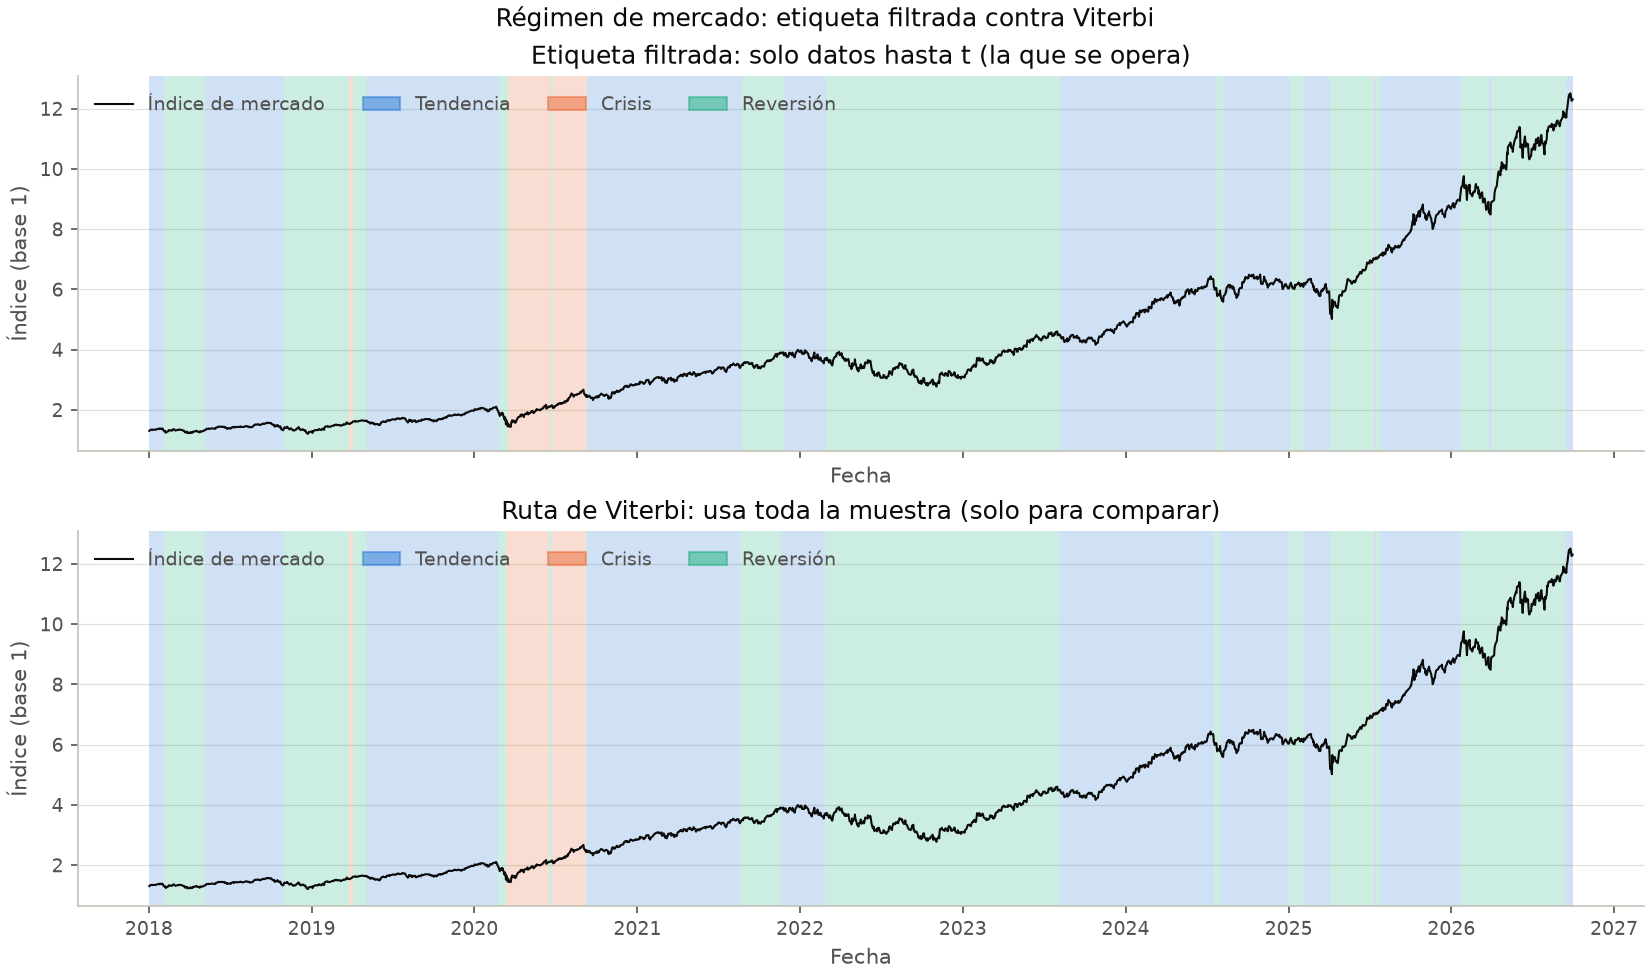

In [6]:
display(Image(filename=FIGURES / "regimen_filtrada_vs_viterbi.png"))

La etiqueta filtrada (arriba) solo usa datos hasta t y es la que se opera. Viterbi (abajo) reetiqueta
el pasado con información futura y por eso se ve más limpia; solo aparece aquí como comparación.

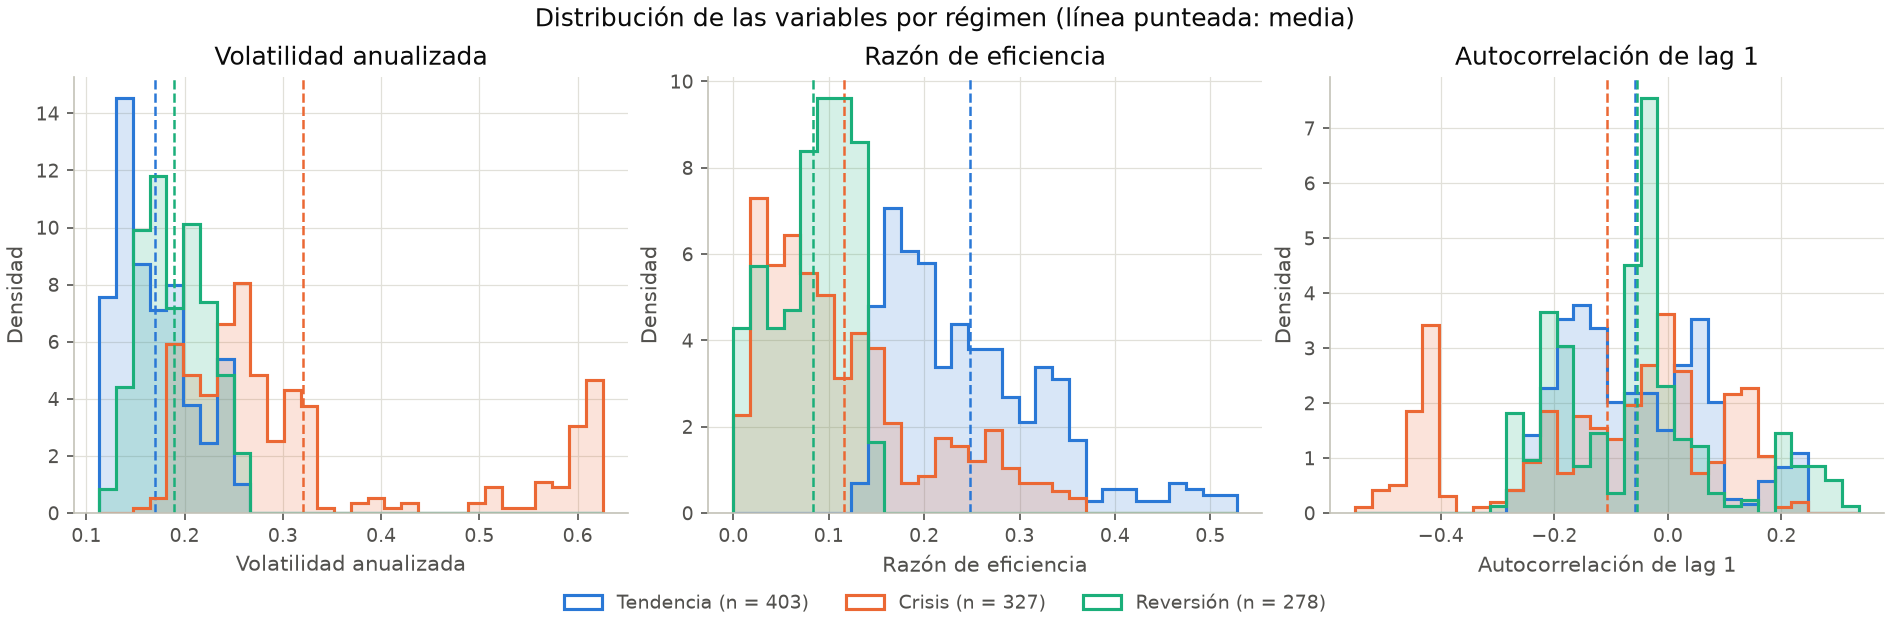

In [7]:
display(Image(filename=FIGURES / "regimen_variables_train.png"))

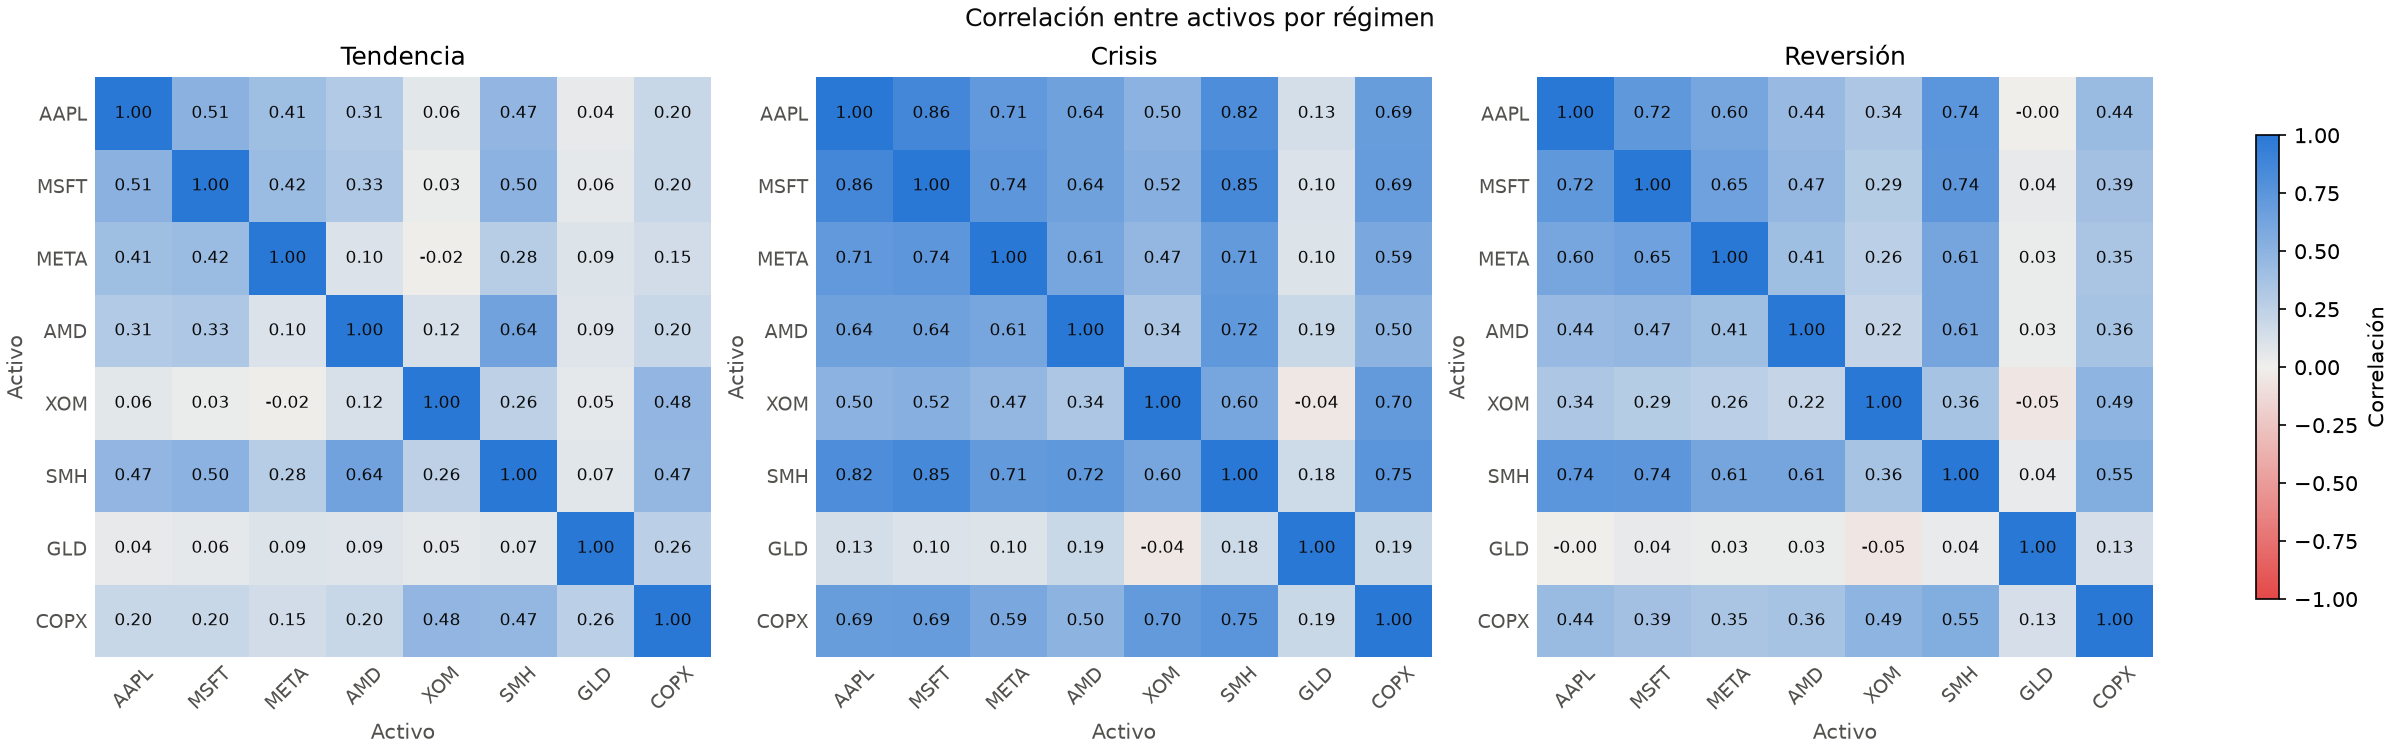

In [8]:
display(Image(filename=FIGURES / "regimen_correlacion_train.png"))

## 4.2 Estudios de diagnóstico sobre train

In [9]:
resumen = pd.DataFrame({k: v["user_attrs"] for k, v in r["diagnostico"]["studies"].items()}).T
display(resumen[["n_trials_evaluated", "n_trials_feasible", "minimum_trades", "elapsed_seconds"]])
display(pd.Series(r["diagnostico"]["plateau"], name="θ* (medoide de la meseta TPE)"))

,n_trials_evaluated,n_trials_feasible,minimum_trades,elapsed_seconds
random,200,199,192,12.1949
tpe,200,200,192,12.1385


sma_fast       19.0000
sma_slow       64.0000
rsi_window     20.0000
rsi_lo         39.0000
rsi_hi         65.0000
k_stop          3.8145
reward_ratio    3.6443
max_holding    40.0000
Name: θ* (medoide de la meseta TPE), dtype: float64

Se hicieron 200 pruebas random y 200 TPE sobre los 4 años de train, con un mínimo de 192
operaciones (24 por cada 6 meses). Casi todas las configuraciones fueron factibles. θ\* es el
medoide del mejor 10% del TPE.

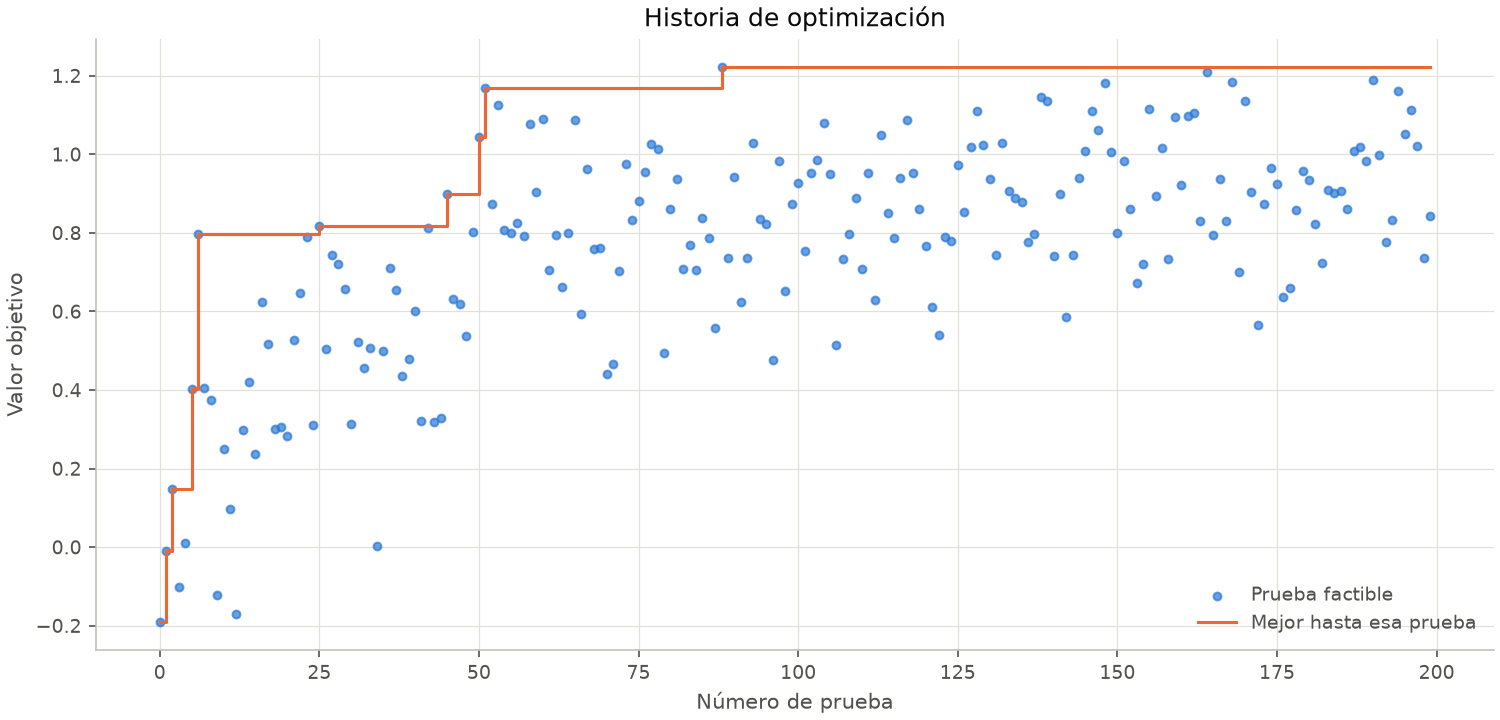

In [10]:
display(Image(filename=FIGURES / "diagnostico_historia_tpe.png"))

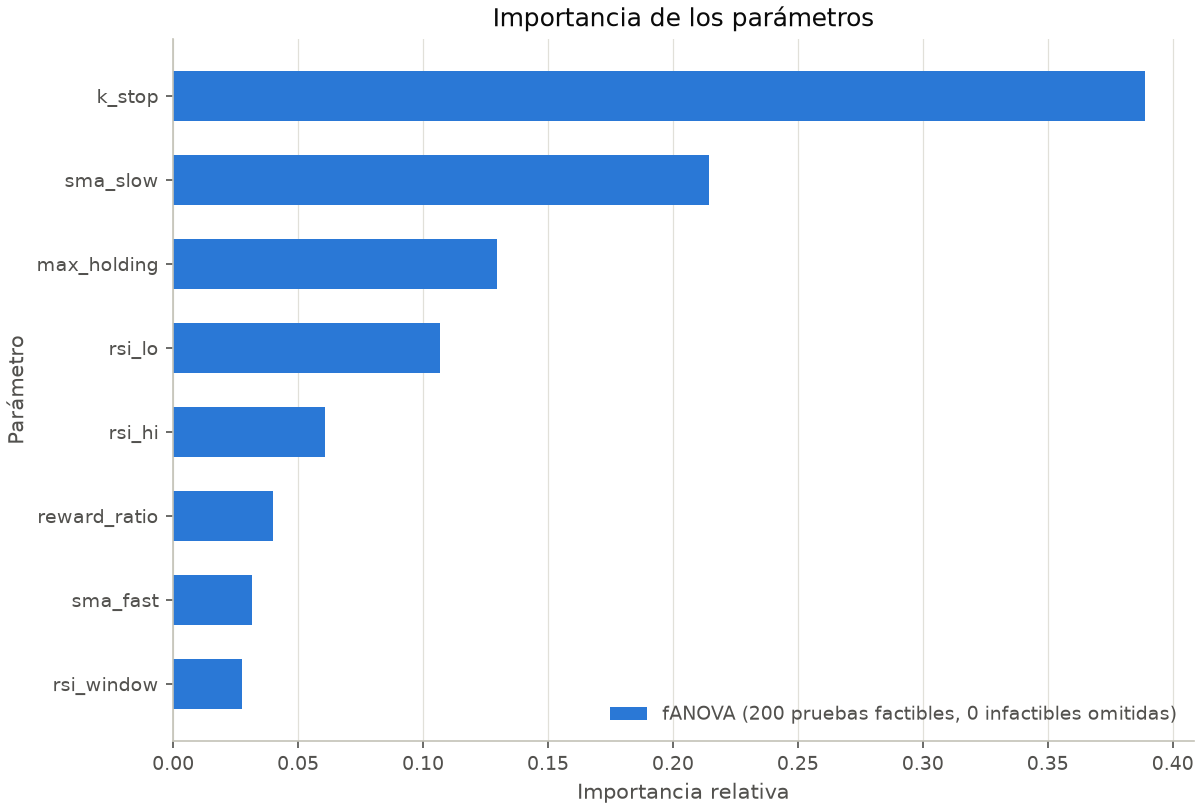

In [11]:
display(Image(filename=FIGURES / "diagnostico_importancia_tpe.png"))

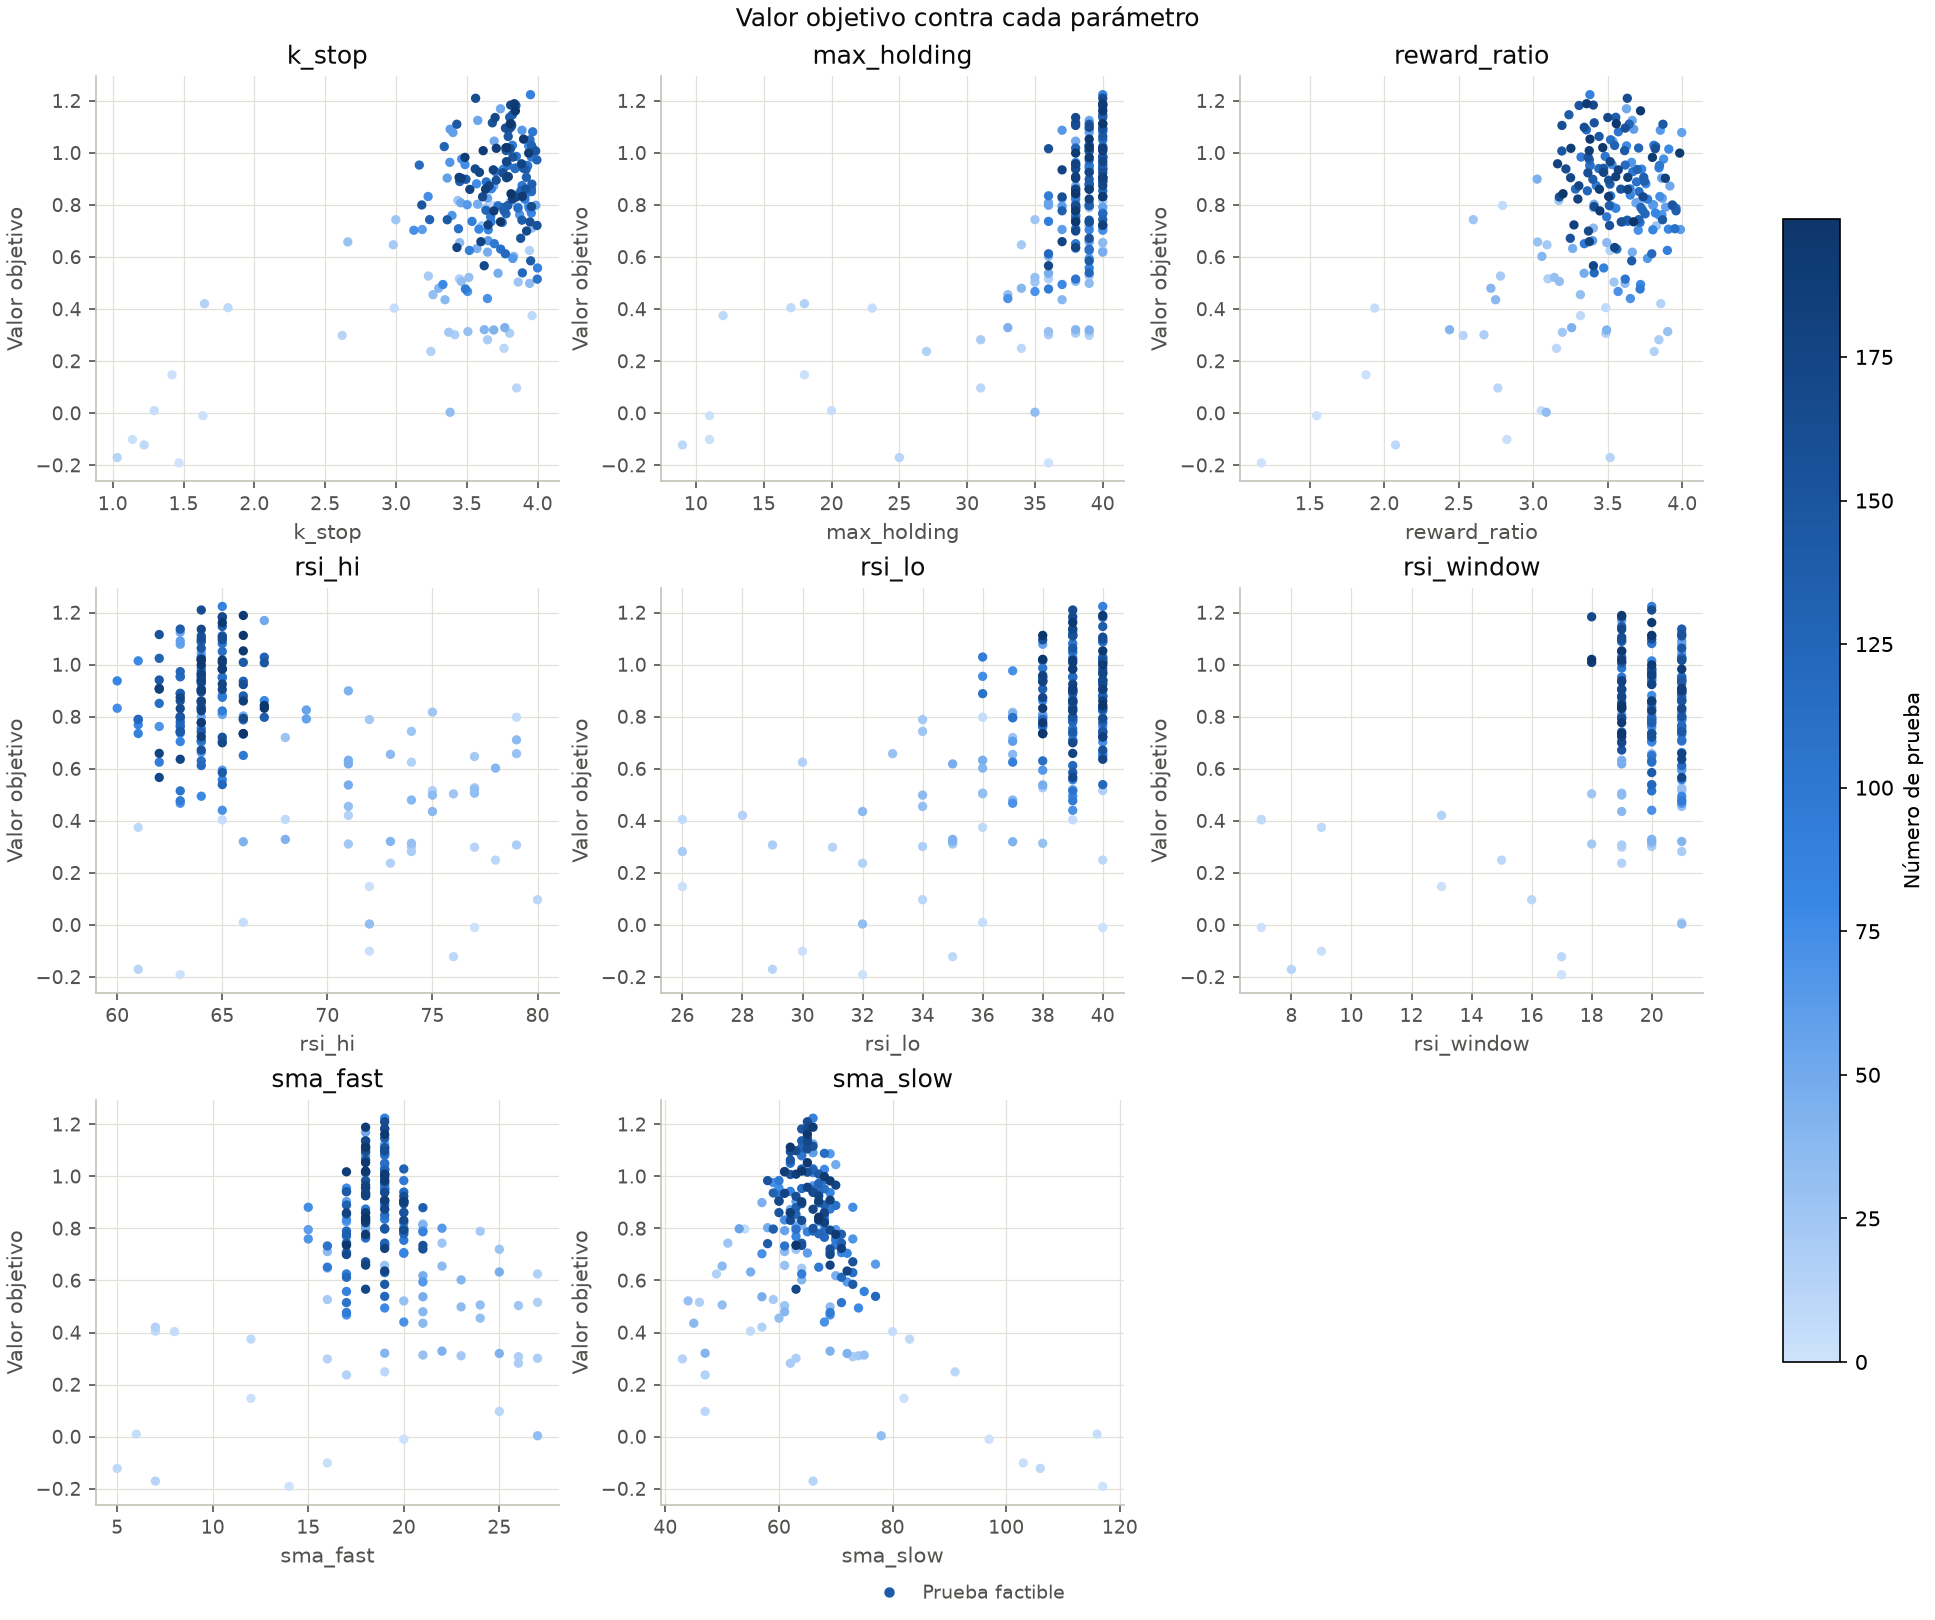

In [12]:
display(Image(filename=FIGURES / "diagnostico_slices_tpe.png"))

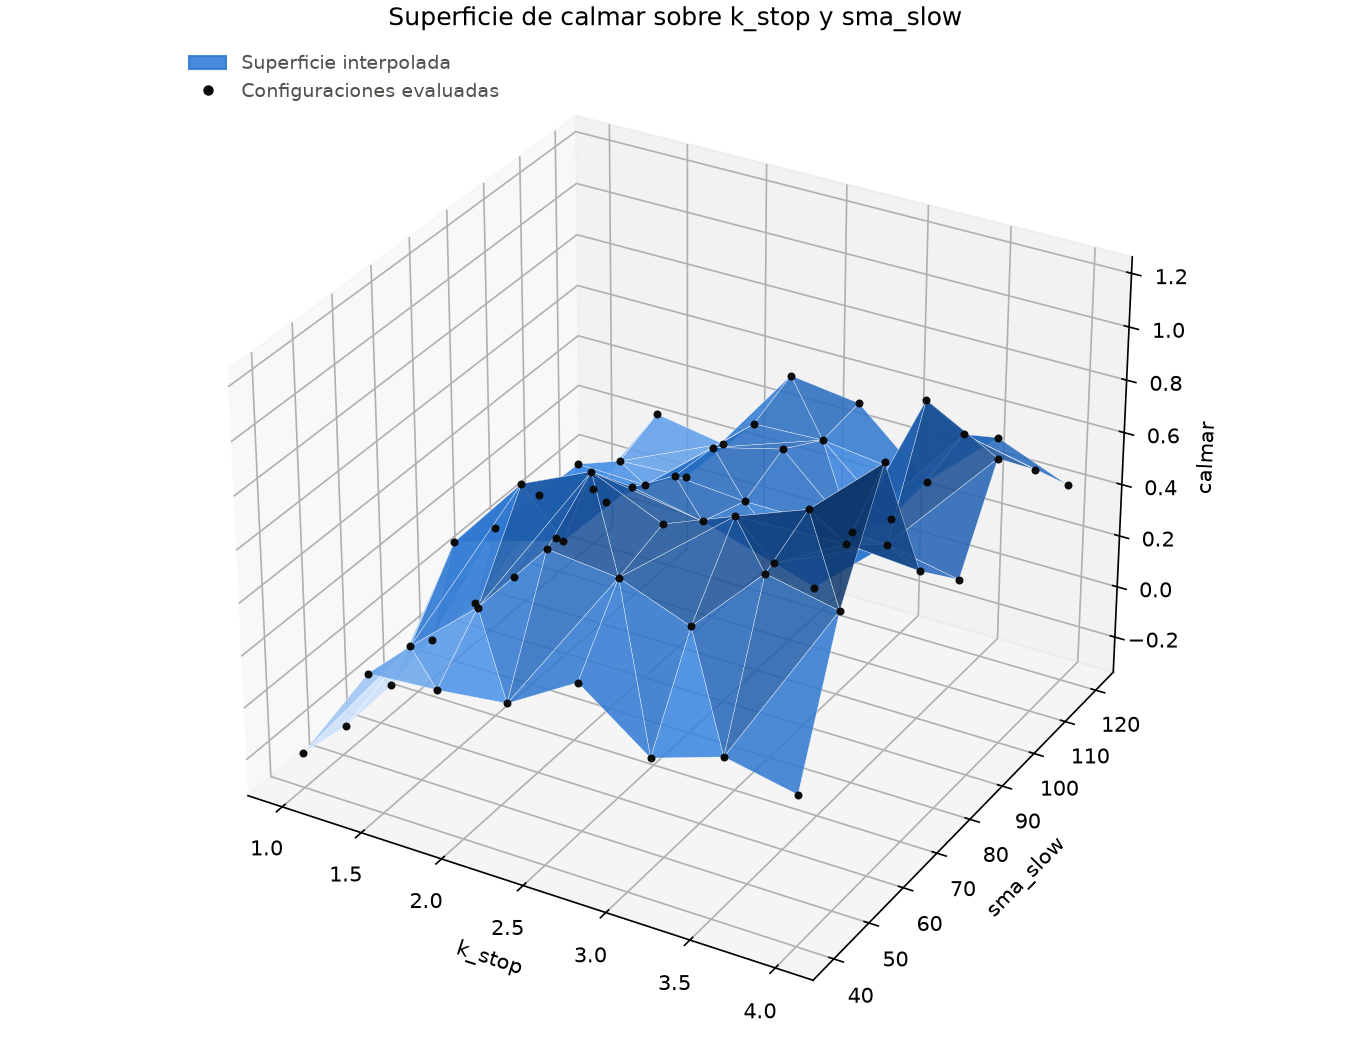

In [13]:
display(Image(filename=FIGURES / "diagnostico_superficie_random.png"))

La superficie es un corte de 2 de las 8 dimensiones: las dos más importantes según fANOVA, con el
resto fijo en la mejor prueba del random search. No existe una superficie completa en más de 2
dimensiones.

## 4.3 Backtest final fuera de muestra

Cada mes opera con los parámetros de su ventana del walk-forward rolling por régimen, de julio de
2018 (primer mes fuera de muestra) a septiembre de 2026. Los bloques se miden por separado; buy &
hold compra 1/8 de cada activo al inicio de cada bloque.

In [14]:
tabla = final["metrics_by_block"][columnas]
display(tabla.loc[["Risk Parity", "Pesos iguales", "Buy & hold"]].round(3))

ann_return  ann_vol  sharpe  sortino  calmar  max_drawdown  n_trades  win_rate
estrategia    bloque                                                                                    
Risk Parity   train           0.0400   0.0510  0.5940   0.8580  0.8190       -0.0480       280    0.4790
              validation     -0.0040   0.0580 -0.6450  -0.8950 -0.0630       -0.0620       145    0.4620
              test            0.0070   0.0720 -0.4550  -0.6020  0.0670       -0.1070       224    0.4550
Pesos iguales train           0.0510   0.0650  0.6460   0.9320  0.8910       -0.0570       280    0.4790
              validation     -0.0040   0.0740 -0.4960  -0.7010 -0.0560       -0.0770       145    0.4620
              test            0.0010   0.0880 -0.4260  -0.5610  0.0080       -0.1480       224    0.4550
Buy & hold    train           0.4000   0.2880  1.2790   1.8440  1.3190       -0.3030         0       NaN
              validation      0.0780   0.2290  0.2890   0.4090  0.3100       -0.2510         0       NaN
              test            0.3840   0.2310  1.3380   2.0110  1.8060       -0.2130         0       NaN

| Bloque | Risk Parity: retorno · Calmar · MDD | Buy & hold: retorno · Calmar · MDD |
|---|---|---|
| Train (jul-2018 a 2021) | 4.0% · 0.82 · −4.8% | 40.0% · 1.32 · −30.3% |
| Validation (2022–2023) | −0.4% · −0.06 · −6.2% | 7.8% · 0.31 · −25.1% |
| Test (2024–sep 2026) | 0.7% · 0.07 · −10.7% | 38.4% · 1.81 · −21.3% |

- **Fuera de muestra, la estrategia es prácticamente plana:** −0.4% anual en validation y +0.7% en
  test. El capital pasa de 1,000,000 a 1,159,068 USD en 8.25 años. Buy & hold multiplicó el capital
  por 10 en el mismo periodo.
- **El Sharpe es negativo en validation y test aunque test tenga retorno positivo.** Se calcula
  sobre el exceso de retorno, y la tasa libre de riesgo promedió 3.5% en 2022–2023 y 4.3% en
  2024–2026: la estrategia no le gana al T-Bill.
- **El drawdown es de 2 a 6 veces menor que el de buy & hold**, porque la exposición media es de
  31% a 39% y hay posiciones cortas.

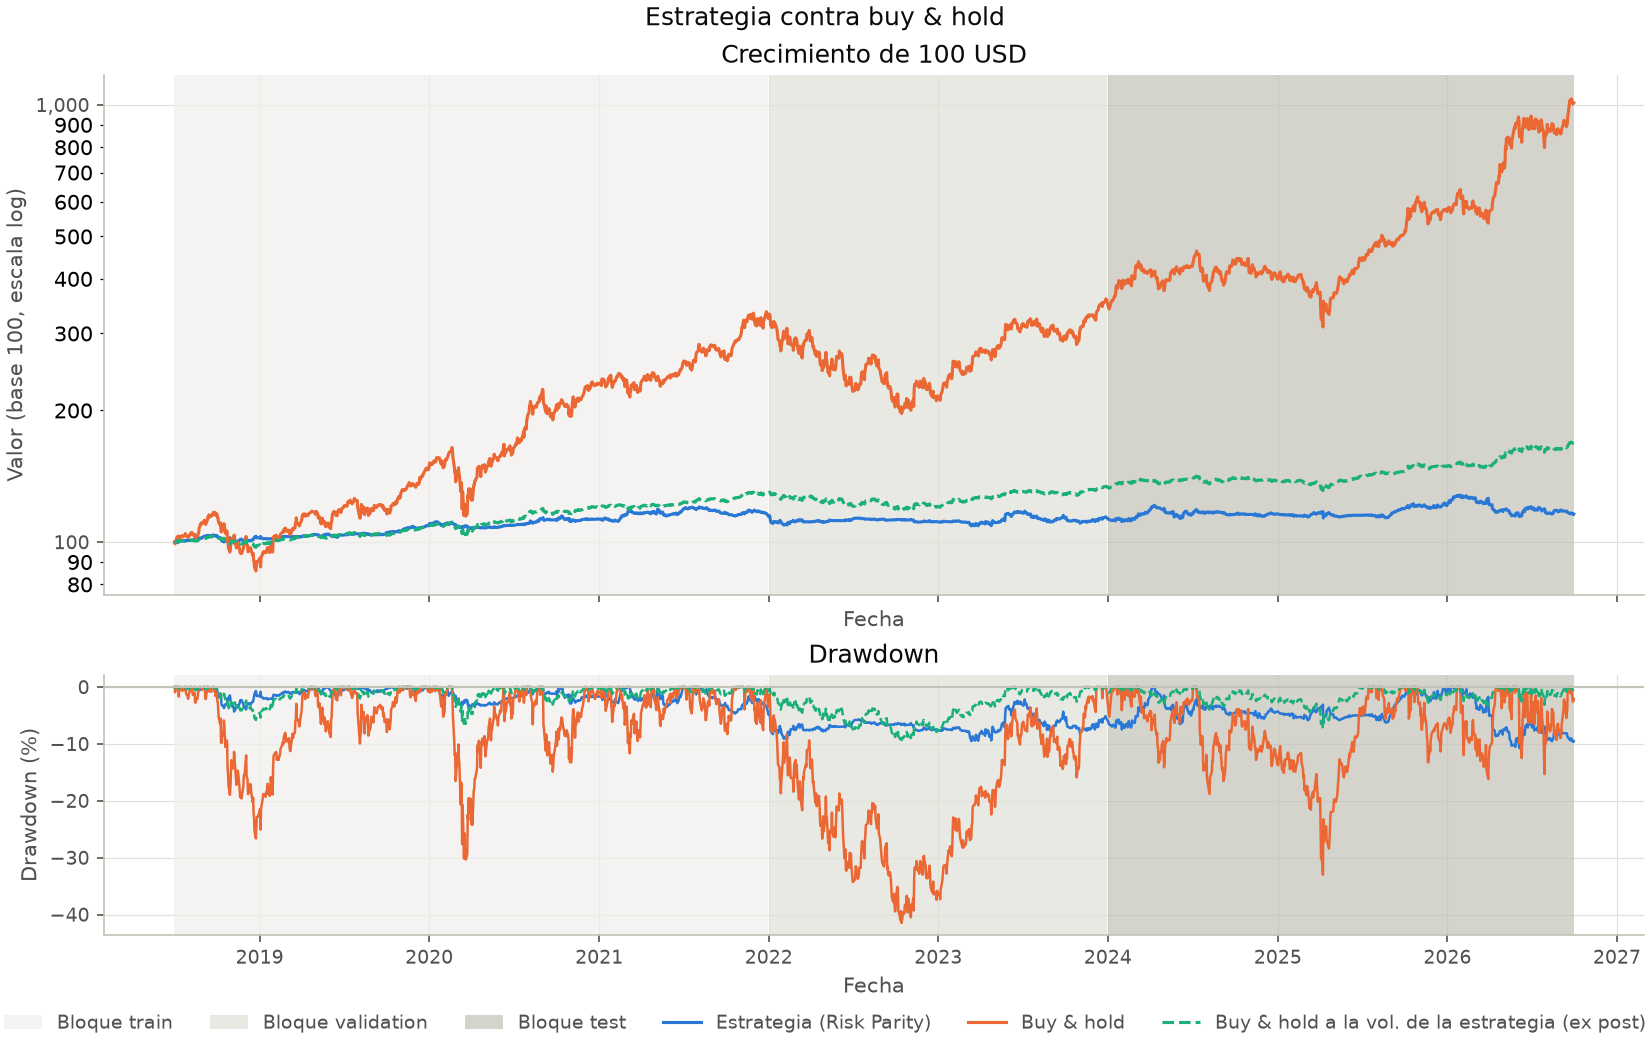

In [15]:
display(Image(filename=FIGURES / "final_vs_buy_and_hold.png"))

In [16]:
display(r["comparacion_buy_hold"]["metrics"][["ann_return", "ann_vol", "sharpe", "calmar", "max_drawdown"]].unstack("bloque").round(3))

ann_return                   ann_vol                   sharpe                    calmar                   max_drawdown  \
bloque                                 train validation   test   train validation   test  train validation    test  train validation   test        train   
estrategia                                                                                                                                                 
Estrategia (Risk Parity)              0.0400    -0.0040 0.0070  0.0510     0.0580 0.0720 0.5950    -0.6450 -0.4550 0.8200    -0.0630 0.0670      -0.0480   
Buy & hold                            0.4000     0.0500 0.4620  0.2880     0.3090 0.3160 1.2790     0.1990  1.2230 1.3190     0.1230 1.3990      -0.3030   
Buy & hold a vol. igual (ex post)     0.0770     0.0180 0.0870  0.0570     0.0620 0.0630 1.1400    -0.2580  0.6800 1.1840     0.1930 1.2000      -0.0650   

                                                      
bloque                            validation    test  
estrategia                                            
Estrategia (Risk Parity)             -0.0620 -0.1070  
Buy & hold                           -0.4070 -0.3300  
Buy & hold a vol. igual (ex post)    -0.0910 -0.0730

**Comparación a igual riesgo.** La línea punteada escala los retornos diarios de buy & hold a la
volatilidad de la estrategia (es ex post, no operable). Aun así, buy & hold gana en los tres bloques:
Sharpe 1.14 contra 0.59 en train y 0.68 contra −0.46 en test. La diferencia no se debe solo a la
menor exposición: la estrategia no tiene un edge que compense la deriva alcista del universo.

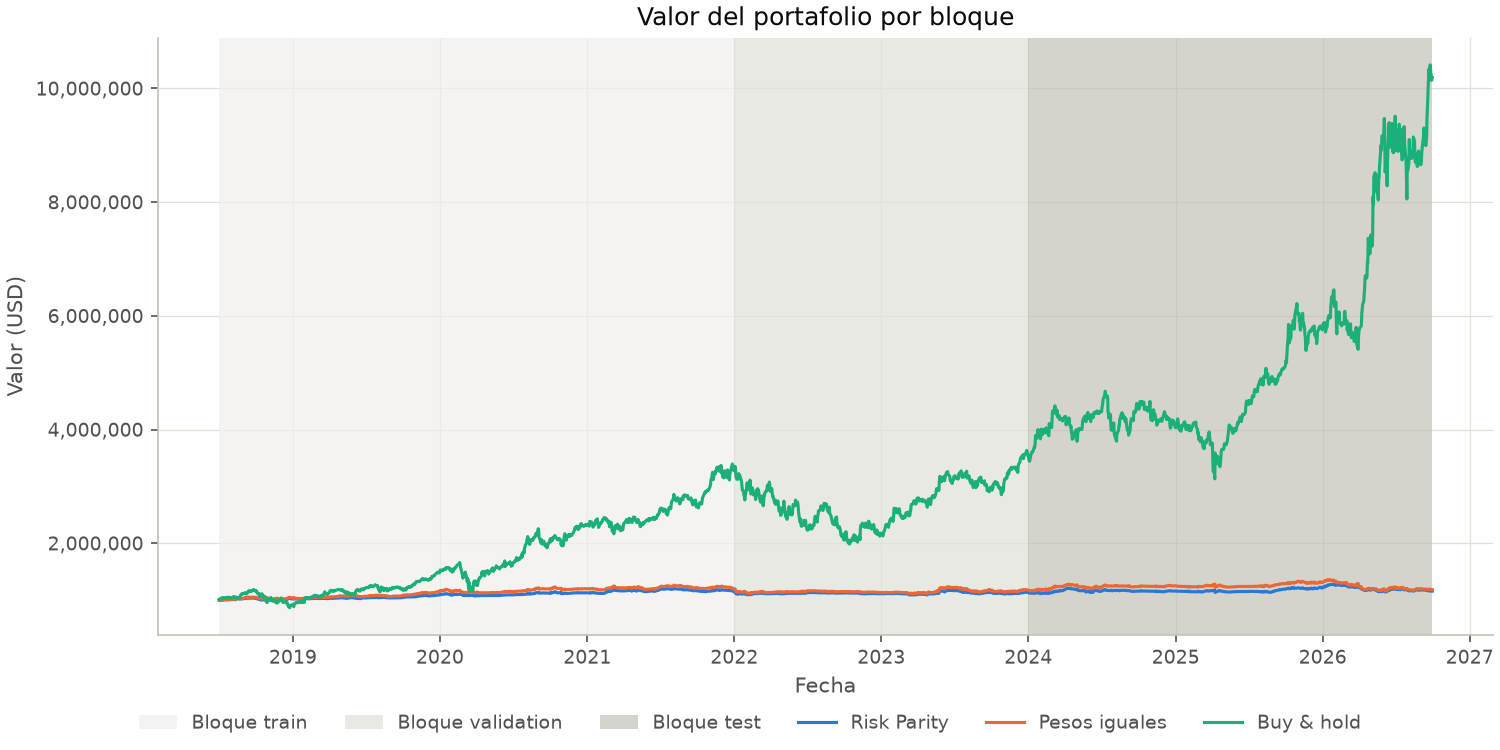

In [17]:
display(Image(filename=FIGURES / "final_equity.png"))

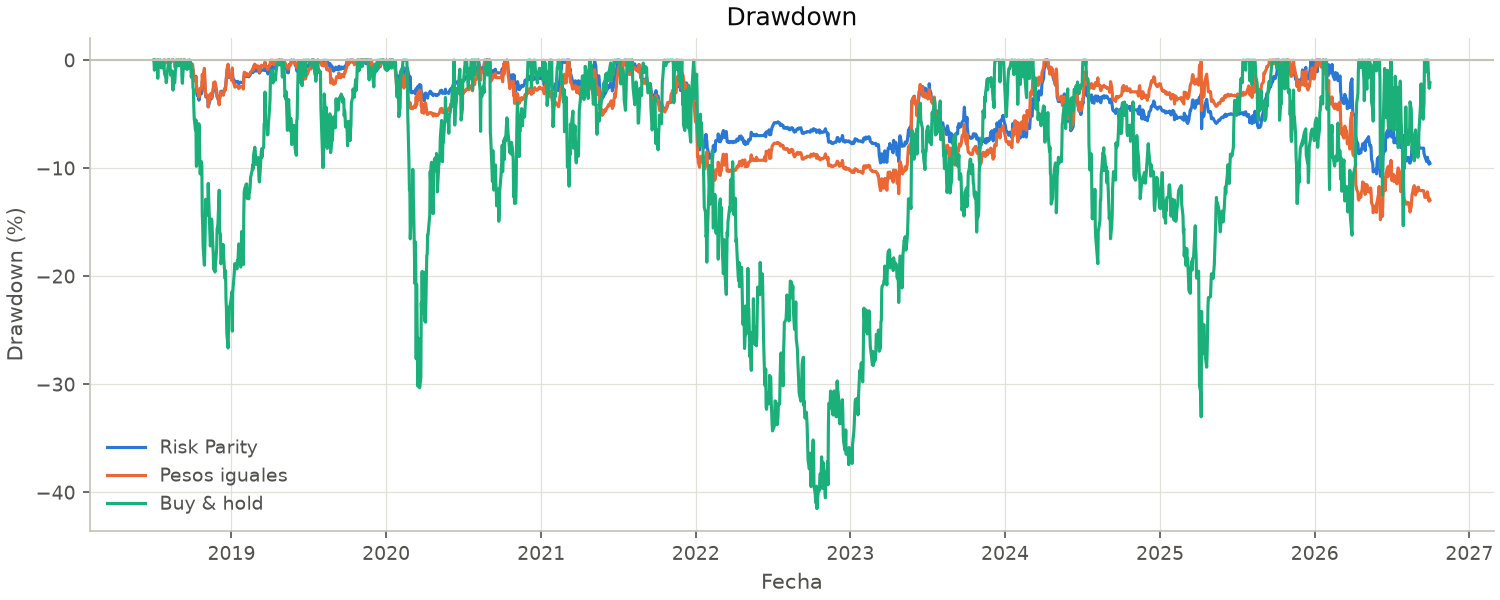

In [18]:
display(Image(filename=FIGURES / "final_drawdown.png"))

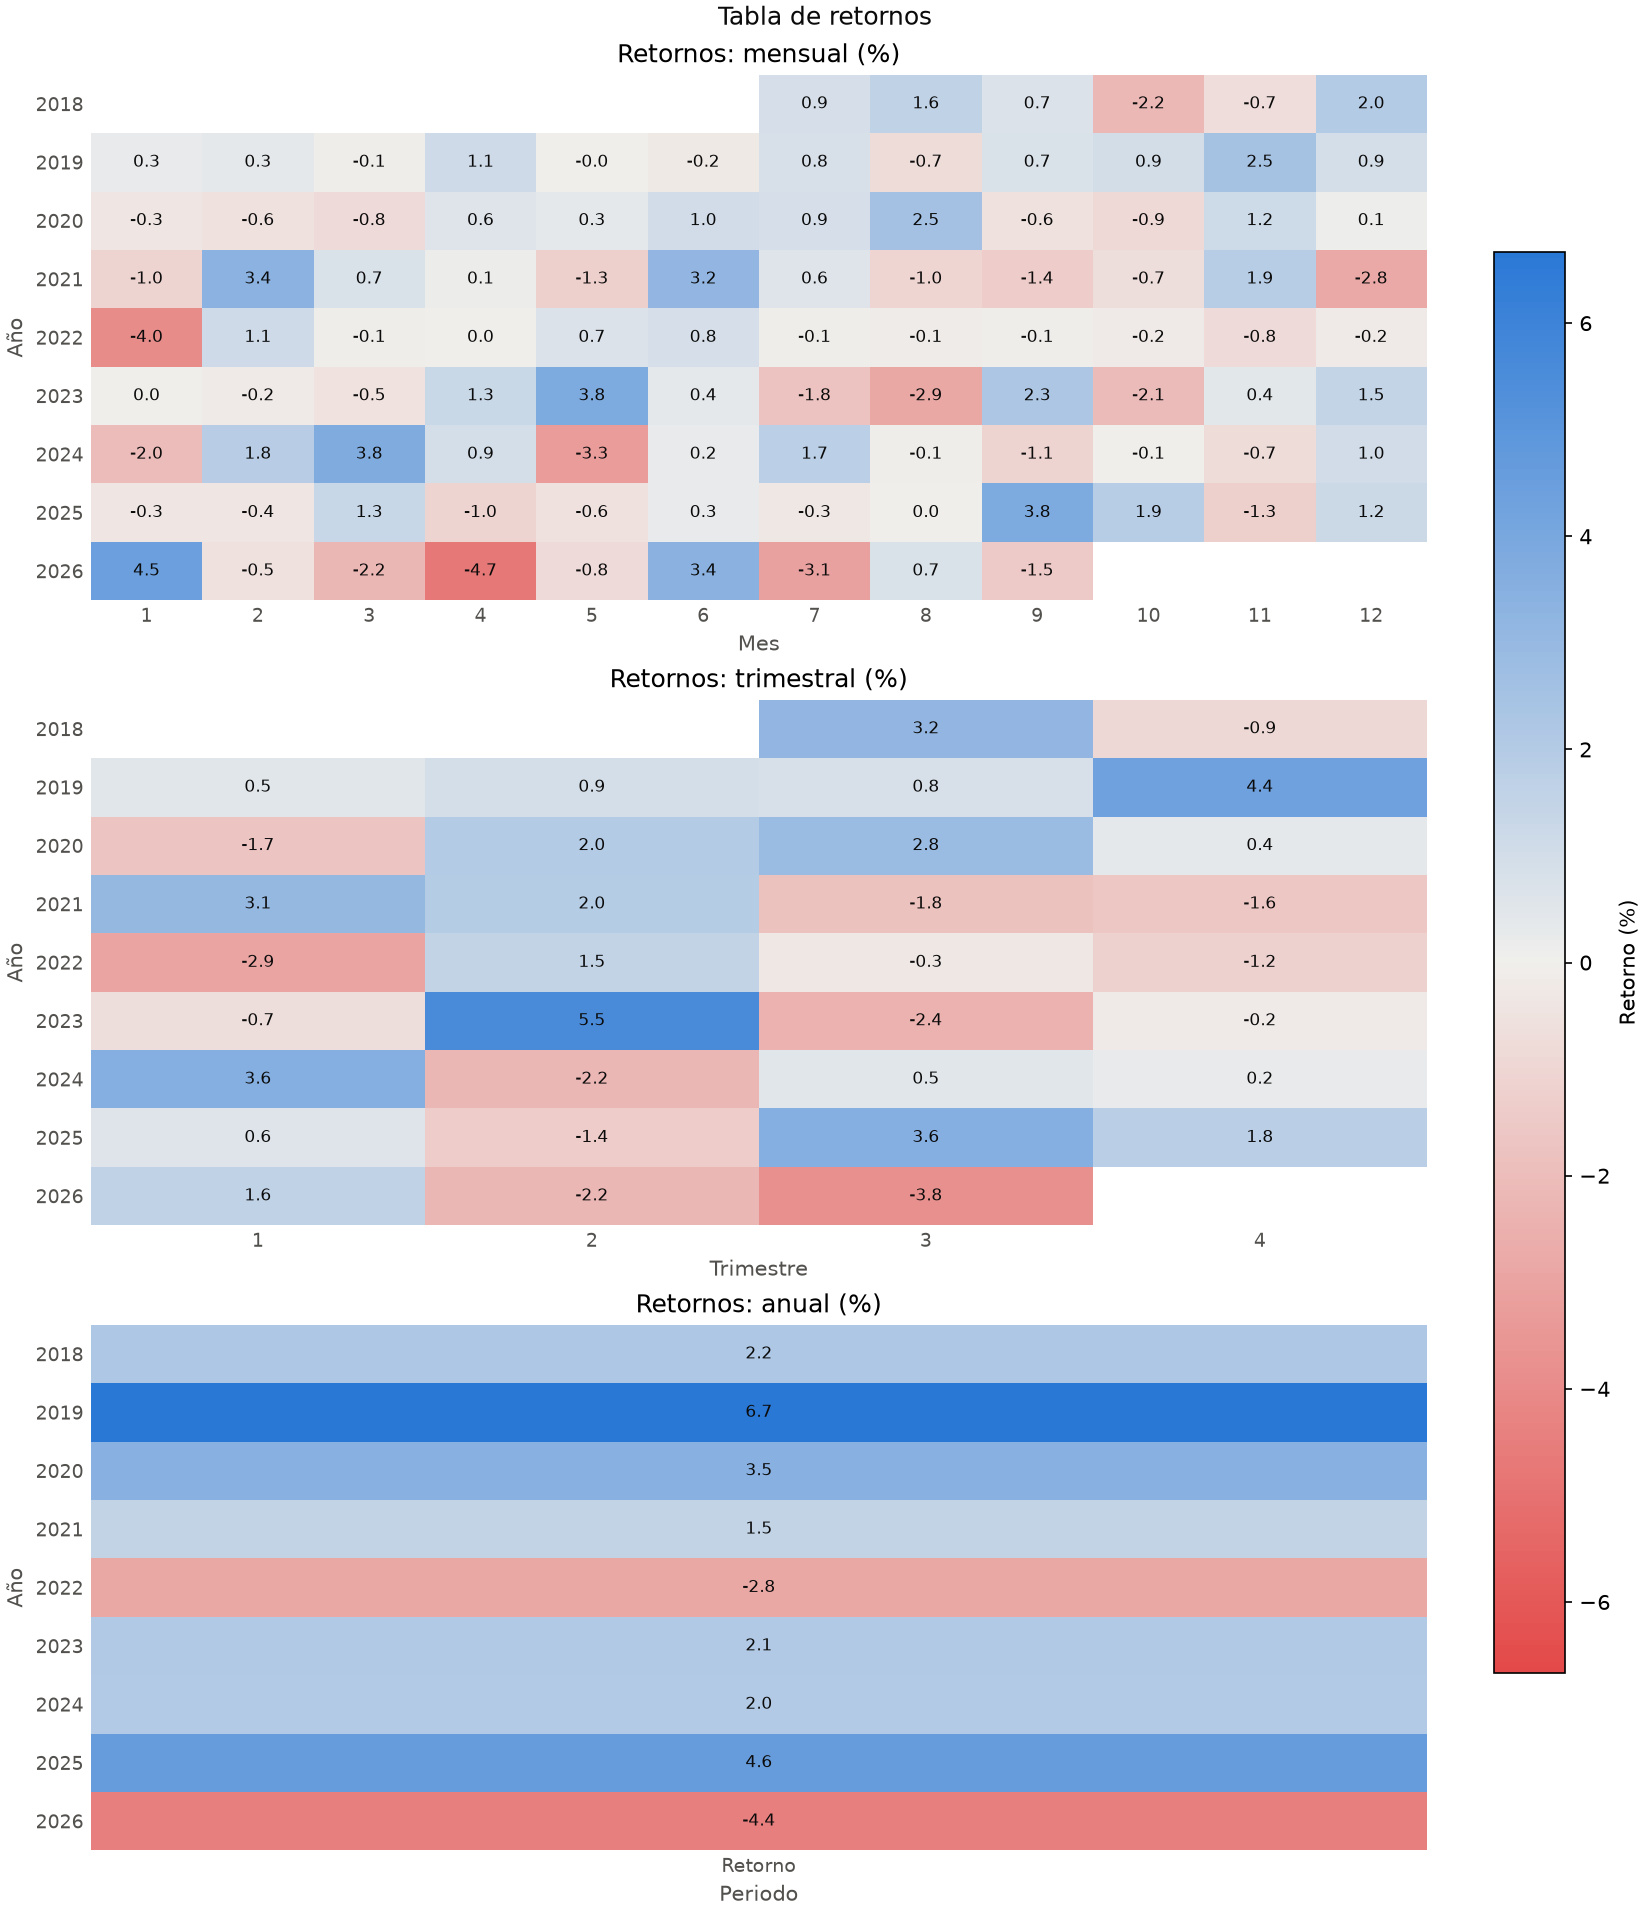

In [19]:
display(Image(filename=FIGURES / "final_retornos_risk_parity.png"))

### Activos individuales (C = Equity en cada activo, con las mismas señales)

In [20]:
display(tabla.drop(index=["Risk Parity", "Pesos iguales", "Buy & hold"])[["ann_return", "sharpe", "calmar", "max_drawdown", "n_trades"]].unstack("bloque").round(3))

ann_return                     sharpe                     calmar                    max_drawdown                    n_trades                
bloque          train validation    test   train validation    test   train validation    test        train validation    test    train validation test
estrategia                                                                                                                                             
AAPL           0.2770     0.1090  0.0500  1.1140     0.4420  0.1330  0.7860     0.6600  0.2180      -0.3520    -0.1650 -0.2280       35         17   26
MSFT           0.0280    -0.1700 -0.0780  0.1920    -0.7730 -0.6740  0.0690    -0.3790 -0.2840      -0.4120    -0.4490 -0.2760       34         22   28
META           0.0280    -0.0730 -0.0820  0.2000    -0.2290 -0.3070  0.1030    -0.2040 -0.1710      -0.2750    -0.3570 -0.4780       33         22   29
AMD           -0.0120     0.1040  0.0240  0.1710     0.3540  0.1610 -0.0220     0.3420  0.0450      -0.5580    -0.3030 -0.5250       38         17   28
XOM            0.0410    -0.1540 -0.0840  0.2540    -0.8870 -0.6430  0.1810    -0.4470 -0.2140      -0.2280    -0.3440 -0.3900       35         17   29
SMH           -0.0050     0.0740 -0.1090  0.0690     0.2680 -0.4320 -0.0150     0.4670 -0.2290      -0.3570    -0.1570 -0.4740       40         14   31
GLD           -0.0000     0.0220  0.0600 -0.0590    -0.0910  0.1820 -0.0020     0.2930  0.2830      -0.1330    -0.0760 -0.2140       35         17   28
COPX           0.1950    -0.1540  0.0330  0.8680    -0.8640  0.1050  0.7410    -0.3710  0.0770      -0.2620    -0.4140 -0.4270       35         22   25

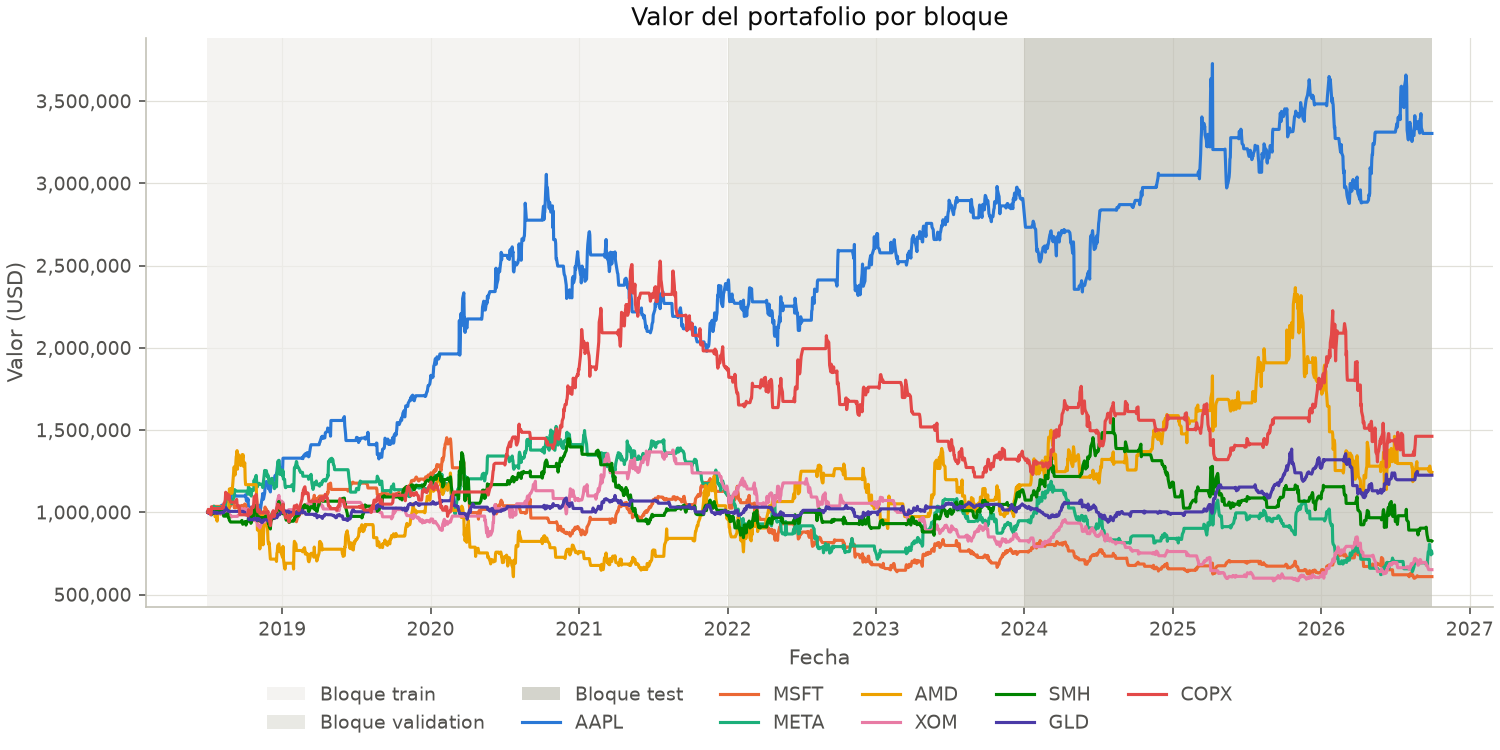

In [21]:
display(Image(filename=FIGURES / "final_equity_activos.png"))

Ningún activo es consistente en los tres bloques. AAPL es el único positivo en todos (27.7%, 10.9% y
5.0% anual), pero con drawdowns de 17% a 35%. El portafolio diversifica: su drawdown (−4.8% a
−10.7%) es mucho menor que el de cualquier activo solo.

### Exposición, salidas y punto de equilibrio

In [22]:
for name, metrics in final["exposure"].items():
    print(f"{name}: tiempo en mercado {metrics['time_in_market_portfolio']:.0%}, "
          f"{metrics['trades_per_month']:.1f} operaciones/mes")
    display(metrics["exit_reasons"].to_frame().T)
display(final["breakeven"])

Risk Parity: tiempo en mercado 81%, 5.5 operaciones/mes


exit_reason,signal,stop,target,max_holding
count,35,202,88,324


Pesos iguales: tiempo en mercado 81%, 5.5 operaciones/mes


exit_reason,signal,stop,target,max_holding
count,35,202,88,324


,theoretical_win_rate,empirical_breakeven_win_rate,observed_win_rate,payoff_ratio,cost_in_r
train,0.2659,0.4399,0.4786,1.2733,0.0418
validation,0.2659,0.4369,0.4621,1.2890,0.0418
test,0.2659,0.4395,0.4554,1.2755,0.0418


- **Exposición y salidas:** hay alguna posición abierta 81% de los días, con 5.5 operaciones por
  mes. Domina la salida por holding máximo (324), seguida de stop (202), target (88) y señal (35).
- **Win rate:** el observado (45.5% a 47.9%) queda justo por encima del equilibrio empírico (43.7% a
  44.0%), que se calcula con el payoff real de ~1.28. El margen es tan delgado que los costos
  (1.4% a 2.2% del equity al año) se comen casi toda la ganancia.

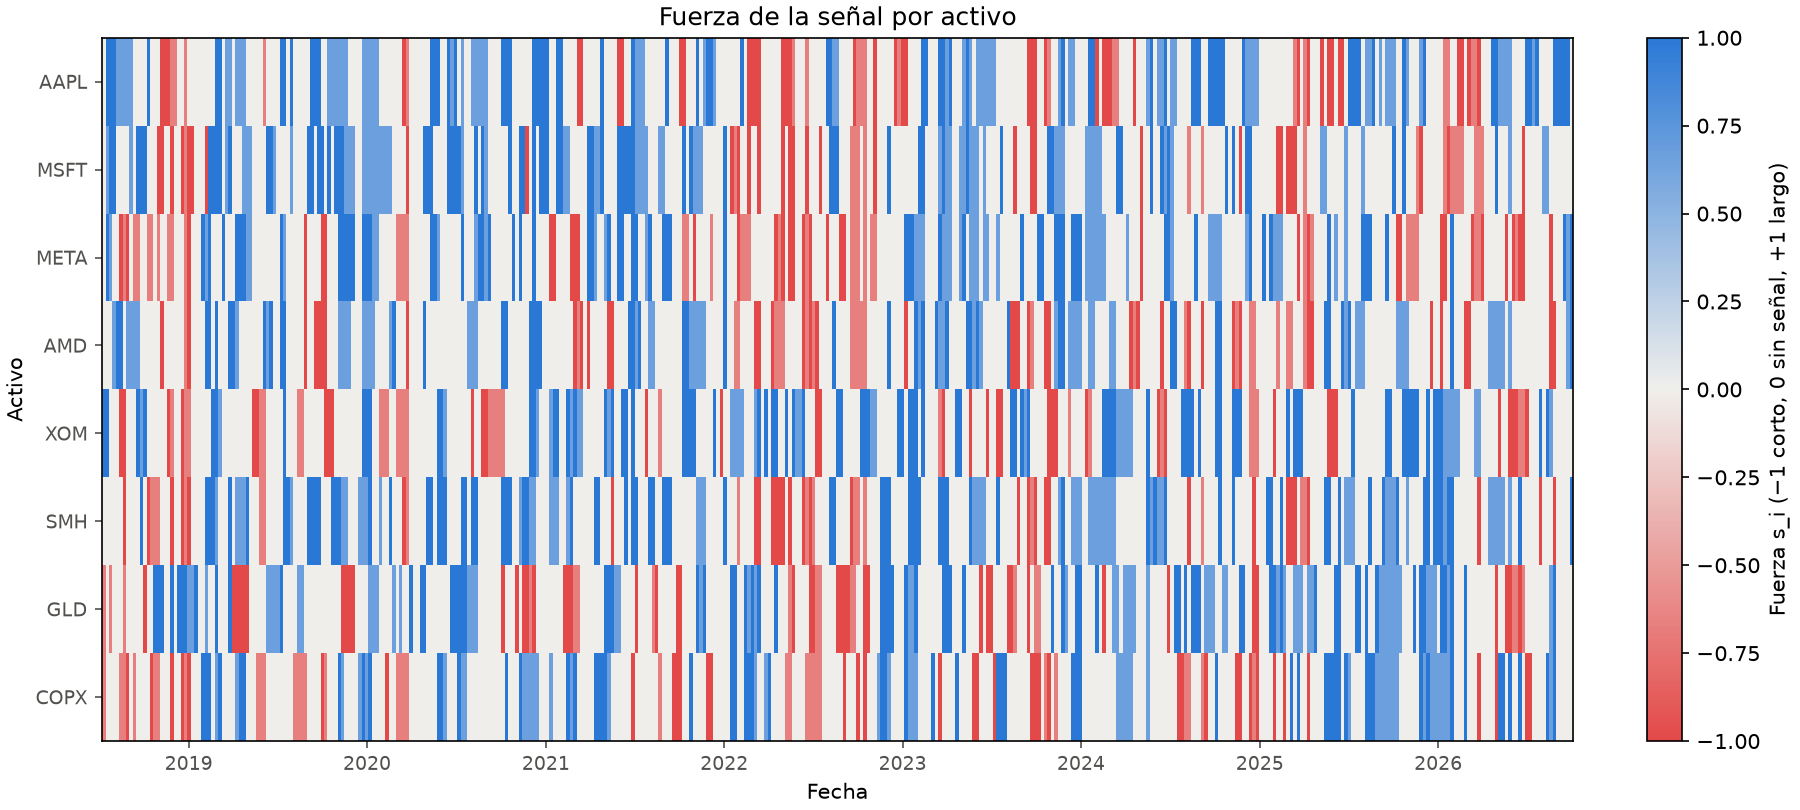

In [23]:
display(Image(filename=FIGURES / "final_mapa_senales.png"))

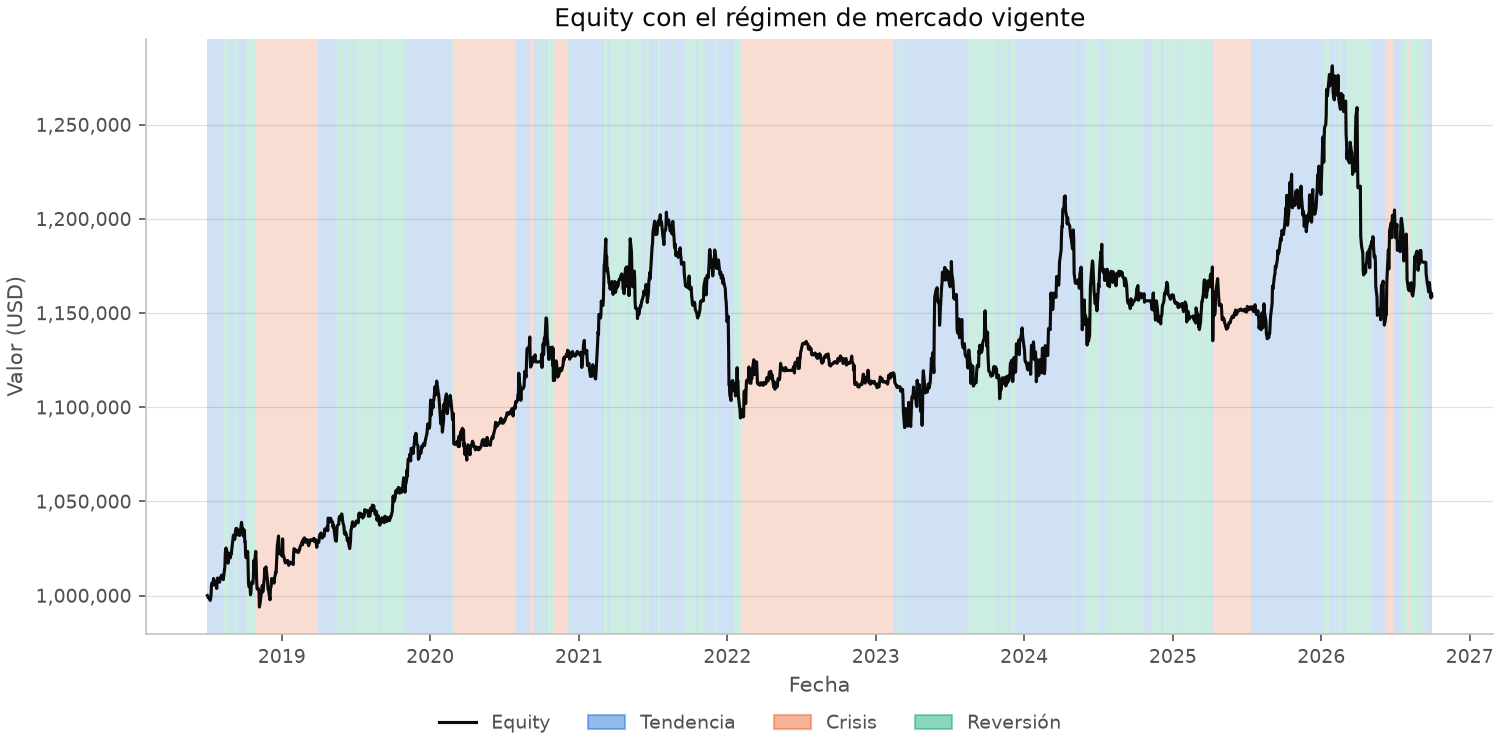

In [24]:
display(Image(filename=FIGURES / "final_equity_regimen.png"))

## 4.4 Portafolio: Risk Parity y decisiones de validation

In [25]:
decisiones = r["decisiones_validation"]
display(decisiones["weight_stability"][["mean_std", "n_reviews"]])
print("Estimador elegido:", decisiones["cov_method"], "· rebalanceo:", decisiones["rebalance"])
display(decisiones["sweep_annualized"])

,mean_std,n_reviews
sample,0.0161,24
ewma,0.0162,24
ledoit_wolf,0.0145,24


Estimador elegido: ledoit_wolf · rebalanceo: ('M', 0.05)


,gross_return,cost,net_return,turnover
W · 0,0.0093,0.0137,-0.0044,0.4877
W · 0.025,0.0100,0.0137,-0.0038,0.3635
W · 0.05,0.0105,0.0138,-0.0033,0.2674
W · 0.1,0.0103,0.0138,-0.0035,0.2278
W · 0.2,0.0074,0.0138,-0.0064,0.0576
M · 0,0.0084,0.0138,-0.0054,0.2824
M · 0.025,0.0088,0.0138,-0.0050,0.2680
M · 0.05,0.0099,0.0138,-0.0039,0.2423
M · 0.1,0.0086,0.0138,-0.0051,0.1974
M · 0.2,0.0062,0.0137,-0.0075,0.0706


En la corrida única de validation, con reglas fijadas antes de verla, Ledoit-Wolf fue el estimador
más estable (0.0145 contra 0.0161 de la muestral y 0.0162 de EWMA). Ninguna combinación de
rebalanceo superó a la mensual con δ = 0.05 por el umbral de 1 punto porcentual. Con
`resize_on_rebalance = False` el rebalanceo solo cambia el tamaño de las entradas nuevas, así que
las 15 combinaciones quedan en un rango de 0.6 pp.

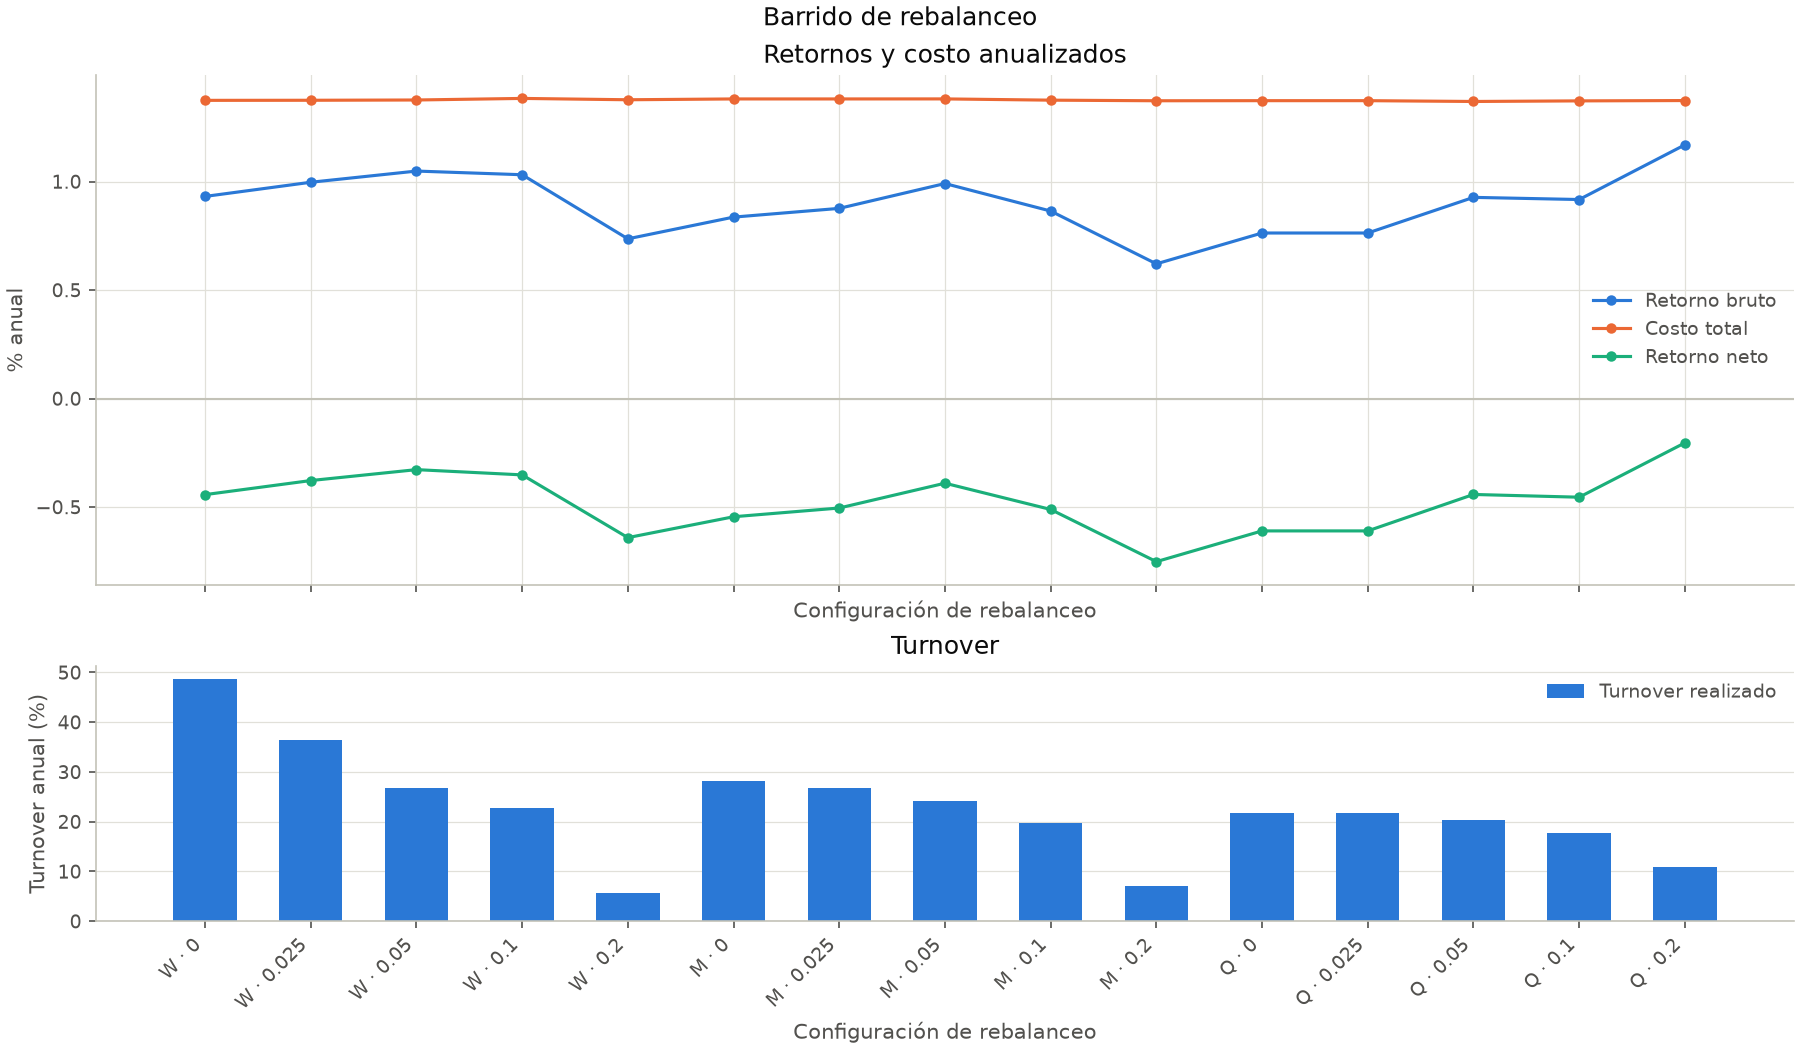

In [26]:
display(Image(filename=FIGURES / "validacion_barrido_rebalanceo.png"))

# 5. Respuestas a las preguntas de análisis

Las preguntas 1, 3 y 4 se miden en train con el θ\* del diagnóstico, congelado antes de validation.
Las preguntas 2, 5 y 6 usan el walk-forward y los backtests finales, con test incluido.

## Pregunta 1. ¿Qué aporta la regla 2 de 3 frente a usar un solo indicador?

In [27]:
display(r["robustez"]["single_indicator"])

,n_trades,calmar
strategy,,
2_de_3,202,1.0827
sma,140,0.3007
macd,561,-0.0655
rsi,673,0.0421


Con el mismo θ\* en train:

| Estrategia | Operaciones | Calmar |
|---|---|---|
| **2 de 3** | **202** | **1.08** |
| SMA sola | 140 | 0.30 |
| RSI solo | 673 | 0.04 |
| MACD solo | 561 | −0.07 |

- **Menos operaciones:** la confirmación recorta 64% de las operaciones de MACD y 70% de las de
  RSI. Esos indicadores cambian de voto con frecuencia, y cada ida y vuelta cuesta 29 bps.
- **Más Calmar:** 1.08 contra 0.30 del mejor indicador solo (SMA). SMA opera menos, pero sin
  confirmación de momento entra tarde y sale más por stop.
- **No son redundantes:** los votos de SMA y MACD tienen correlación de −0.135 en train, así que la
  regla combina información distinta.

## Pregunta 2. ¿Cuánto se degrada el desempeño entre entrenamiento y prueba en el walk-forward?

In [28]:
eficiencia = pd.DataFrame({"ann_return": wf["efficiency"], "calmar": wf["efficiency_calmar"]})
eficiencia.index.names = ["modo", "por_regimen"]
display(eficiencia)
print(f"Configuraciones evaluadas: {wf['n_trials_total']:,} · tiempo de optimización: "
      f"{wf['elapsed_seconds'] / 60:,.1f} min")
ventanas = wf["folds"][("rolling", True)]
bloque = pd.cut(ventanas["test_start"], [pd.Timestamp("2000"), pd.Timestamp("2021-12-31"),
                pd.Timestamp("2023-12-31"), pd.Timestamp("2030")], labels=["train", "validation", "test"])
display(ventanas.groupby(bloque, observed=True)[["is_calmar", "oos_calmar", "is_ann_return", "oos_ann_return"]].median())

ann_return  calmar
modo     por_regimen                    
rolling  True             0.1522  0.0268
         False           -0.1741 -0.0141
anchored True            -0.1384 -0.0267
         False           -0.0726 -0.0150

Configuraciones evaluadas: 131,850 · tiempo de optimización: 37.9 min


,is_calmar,oos_calmar,is_ann_return,oos_ann_return
test_start,,,,
train,7.0059,2.8811,0.1106,0.0339
validation,2.4947,-0.7557,0.0505,-0.0051
test,3.4200,-0.6354,0.0822,-0.0101


La degradación es fuerte. Se evaluaron 131,850 configuraciones en 38 minutos de optimización.

- **Eficiencia del walk-forward rolling por régimen** (retorno OOS concatenado / retorno IS
  promedio): **0.15**, y 0.03 con Calmar. Solo sobrevive alrededor de **15% de la ventaja
  in-sample**, muy por debajo del umbral de ~0.5. Las otras tres variantes tienen eficiencia
  negativa.
- **Calmar mediano por ventana:**

  | Ventanas | Calmar IS | Calmar OOS |
  |---|---|---|
  | Validation | 2.5 | −0.8 |
  | Test | 3.4 | −0.6 |

  Lo que la optimización encuentra en 6 meses no se repite el mes siguiente.
- **Las ventanas de train salen mejor (IS 7.0, OOS 2.9), pero están infladas:** los parámetros de
  indicadores se fijaron con todo train, así que esas ventanas no son del todo fuera de muestra.
- **Rolling contra anchored:** la ventana anchored no corrige el problema. Su OOS en test es aún
  peor (Calmar mediano −2.4). El edge no es estable en el tiempo: decae.

## Pregunta 3. ¿Qué tan sensible es la estrategia a ±20% en sus parámetros? ¿Meseta o pico aislado?

In [29]:
sensibilidad = r["robustez"]["sensitivity"]
display(sensibilidad.pivot_table(index="parameter", columns="factor", values="calmar"))
print(f"Calmar base: {sensibilidad['baseline_calmar'].iloc[0]:.2f}")

factor,0.8000,1.2000
parameter,,
k_stop,0.9840,1.1193
max_holding,0.6385,1.1286
reward_ratio,0.9999,1.1228
rsi_hi,0.6440,1.0665
rsi_lo,0.8709,1.2715
rsi_window,1.1515,0.9817
sma_fast,0.8024,0.7074
sma_slow,0.7412,0.4327


Calmar base: 1.08


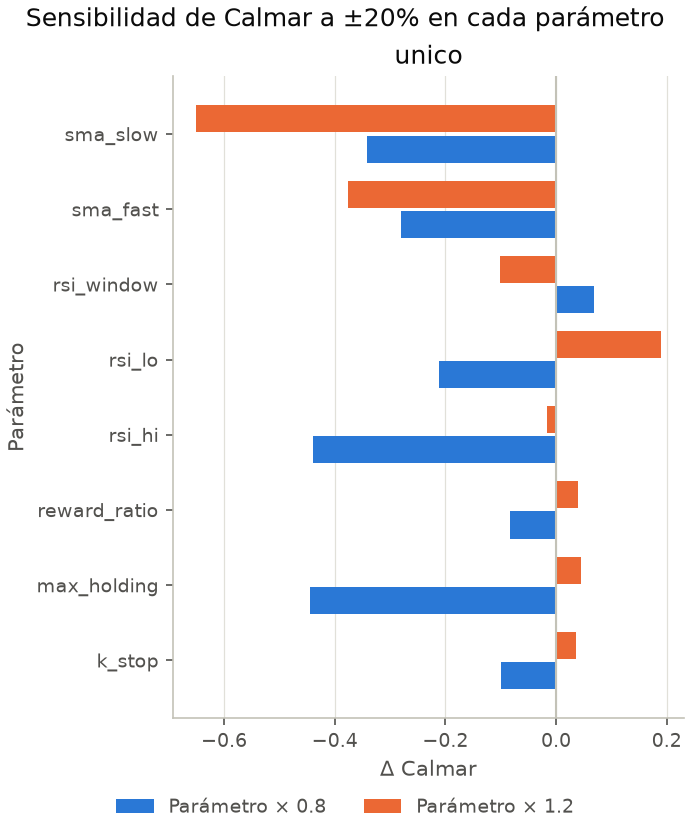

In [30]:
display(Image(filename=FIGURES / "robustez_sensibilidad.png"))

Es una **meseta moderada, no un pico aislado**, con la excepción de las medias móviles. Sobre un
Calmar base de 1.08:

- **Parámetros de salida (k, r):** ±20% mueve el Calmar entre −0.10 y +0.04.
- **En conjunto:** la mediana de las 16 variaciones conserva 91% del Calmar, y 14 de 16 conservan
  más de la mitad.
- **Lo más frágil:** `sma_slow` (×1.2 → −0.65), `max_holding` (×0.8 → −0.44), `rsi_hi` (×0.8 →
  −0.44) y `sma_fast` (−0.28 y −0.38).

Esto respalda haber elegido el centro de la meseta y no el máximo. Pero la meseta es in-sample: la
pregunta 2 muestra que ni siquiera un θ estable en train se sostiene fuera de muestra.

## Pregunta 4. ¿A qué costo deja de ser rentable? ¿Qué margen hay frente al 0.125%?

In [31]:
display(r["robustez"]["cost_curve"][["net_return", "calmar"]].loc[[0.0, 25.0, 30.0, 50.0, 75.0, 100.0]])

,net_return,calmar
round_trip_bps,,
0.0000,0.1314,1.2742
25.0000,0.1154,1.1087
30.0000,0.1122,1.0762
50.0000,0.0996,0.9484
75.0000,0.0841,0.7749
100.0000,0.0688,0.5983


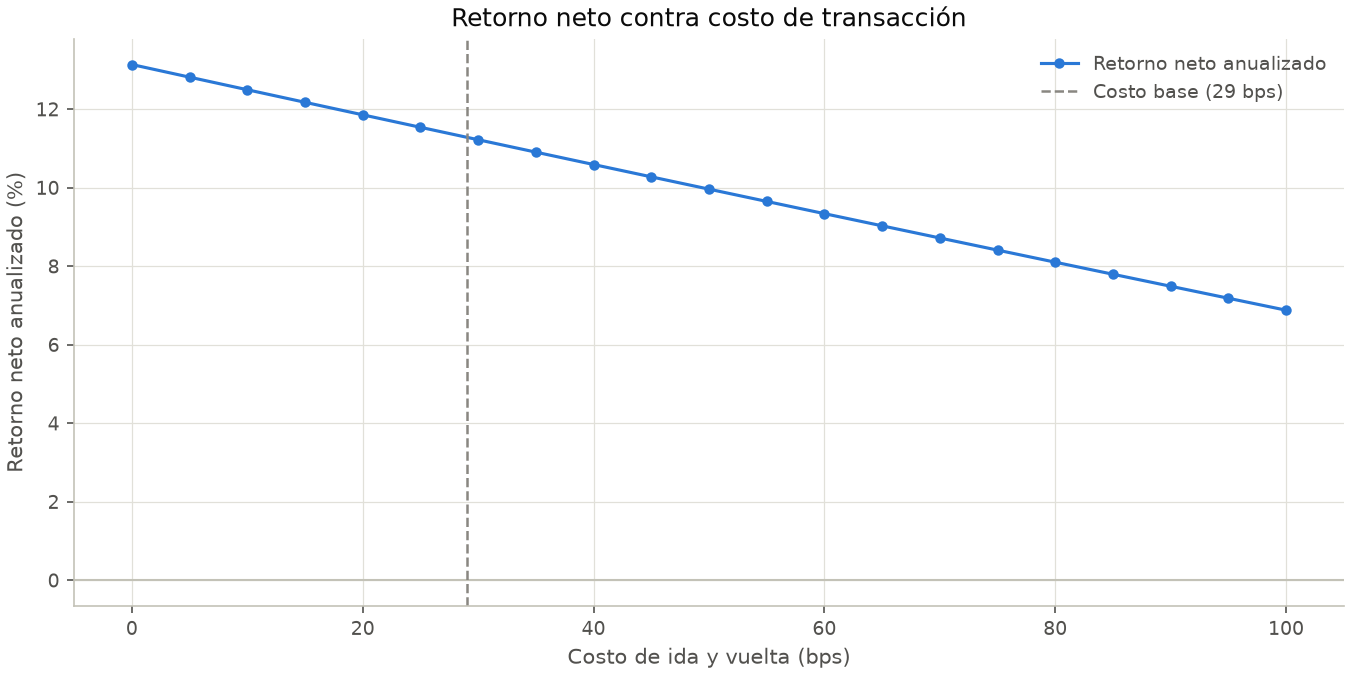

In [32]:
display(Image(filename=FIGURES / "robustez_costos.png"))

**En train, con θ\*, la estrategia es rentable en todo el barrido de 0 a 100 bps de ida y vuelta.**
El retorno neto anual pasa de 13.1% sin costos a 11.2% con ~30 bps y a 6.9% con 100 bps. El caso
base es de 29 bps: 2 × (0.125% + 0.02%). El equilibrio queda por encima de 100 bps, así que el
margen de seguridad es **mayor a 71 bps**, más del triple del costo especificado.

**Fuera de muestra el margen desaparece.** Con los costos base, la estrategia gana −0.4% anual en
validation y +0.7% en test, mientras los costos son de 1.4% a 2.2% del equity al año. Sin costos,
el resultado fuera de muestra sería de ~1% anual en validation y ~3% en test. El equilibrio real
queda alrededor de los 29 bps especificados (debajo en validation, apenas arriba en test): el
margen es casi nulo.

## Pregunta 5. ¿El desempeño difiere de forma significativa entre regímenes? ¿Qué aporta la capa de régimen?

In [33]:
por_regimen = r["regimen_desempeno"]["by_regime"].loc[("rolling", "por régimen")]
display(por_regimen[["n_days", "ann_return", "sharpe", "max_drawdown", "n_trades", "win_rate"]])
display(r["regimen_desempeno"]["theta_comparison"].loc["rolling"][["ann_return", "sharpe", "calmar", "max_drawdown"]])

/var/folders/20/xvvxf3fd0bsc8mhjgvpylzzc0000gn/T/ipykernel_26800/2376811464.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  por_regimen = r["regimen_desempeno"]["by_regime"].loc[("rolling", "por régimen")]


n_days  ann_return  sharpe  max_drawdown  n_trades  win_rate
bloque     regimen                                                                 
train      tendencia 373.0000      0.0864  1.4440       -0.0381  106.0000    0.4057
           reversion 272.0000     -0.0295 -0.7566       -0.0576   61.0000    0.3443
           crisis    237.0000      0.0057 -0.0922       -0.0316   50.0000    0.6000
validation tendencia 152.0000     -0.0076 -0.6700       -0.0528   26.0000    0.0769
           reversion  93.0000     -0.0830 -2.6201       -0.0403   20.0000    0.3000
           crisis    256.0000      0.0088 -0.4579       -0.0269   82.0000    0.4878
test       tendencia 337.0000      0.0754  0.4523       -0.0621   63.0000    0.2381
           reversion 274.0000     -0.0366 -1.2909       -0.0694  106.0000    0.4623
           crisis     78.0000     -0.0253 -0.7597       -0.0347   23.0000    0.4783

ann_return  sharpe  calmar  max_drawdown
variante    bloque                                              
por régimen train           0.0277  0.3667  0.4571       -0.0607
            validation     -0.0138 -0.8981 -0.2060       -0.0671
            test            0.0180 -0.3293  0.1857       -0.0968
θ único     train           0.0120  0.0630  0.1917       -0.0624
            validation     -0.0383 -1.4965 -0.4113       -0.0930
            test           -0.0350 -1.1661 -0.2847       -0.1229

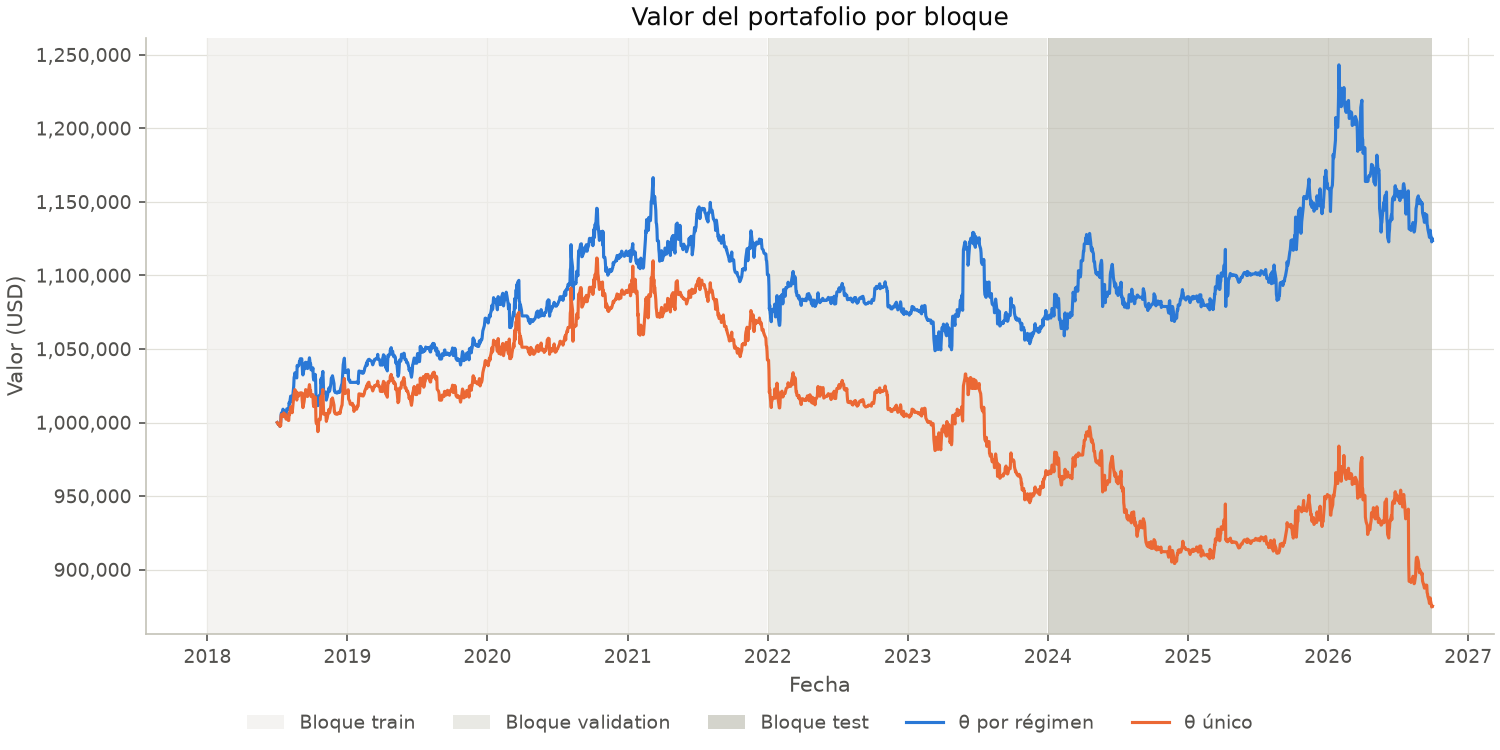

In [34]:
display(Image(filename=FIGURES / "regimen_theta_por_regimen_vs_unico.png"))

**Sí difiere, y de forma consistente en reversión.** Sharpe por régimen (walk-forward rolling por
régimen):

| Régimen | Train | Validation | Test |
|---|---|---|---|
| Tendencia | 1.44 (+8.6% anual) | −0.67 | 0.45 (+7.5% anual) |
| Reversión | −0.76 | −2.62 | −1.29 |
| Crisis | −0.09 | −0.46 | −0.76 |

- **Tendencia** es positiva en train y test y solo falla en 2022.
- **Reversión** pierde en los tres bloques: una estrategia de seguimiento de señales no funciona en
  un mercado sin dirección.

El patrón es coherente, pero cada celda tiene entre 78 y 373 días, así que no es una diferencia
estadísticamente robusta.

Lo que aporta la capa de régimen:

- **θ por régimen contra θ único:** gana en los tres bloques. En test, +1.8% anual contra −3.5%; en
  validation, −1.4% contra −3.8%; en train, 2.8% contra 1.2%. Adaptar las salidas (k, r, m) al
  régimen es la parte de la estrategia que sí se sostiene fuera de muestra.
- **m(régimen):** reduce la exposición en reversión (0.7) y crisis (0.3), justo donde la estrategia
  pierde. Los resultados sugieren que reversión merecía un multiplicador menor, pero no se ajustó a
  posteriori.

## Pregunta 6. ¿Risk Parity mejora el Calmar frente a pesos iguales? ¿A costa de qué?

In [35]:
display(tabla.loc[["Risk Parity", "Pesos iguales"]][["ann_return", "ann_vol", "calmar", "max_drawdown"]].unstack("bloque").round(3))
display(r["portafolio"]["risk_contributions"])

ann_return                   ann_vol                   calmar                   max_drawdown                   
bloque             train validation   test   train validation   test  train validation   test        train validation    test
estrategia                                                                                                                   
Risk Parity       0.0400    -0.0040 0.0070  0.0510     0.0580 0.0720 0.8190    -0.0630 0.0670      -0.0480    -0.0620 -0.1070
Pesos iguales     0.0510    -0.0040 0.0010  0.0650     0.0740 0.0880 0.8910    -0.0560 0.0080      -0.0570    -0.0770 -0.1480

,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,spread,ann_vol
risk_parity,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.0000,0.1659
equal,0.1303,0.1170,0.1336,0.2365,0.0871,0.1483,0.0162,0.1309,0.2206,0.2218


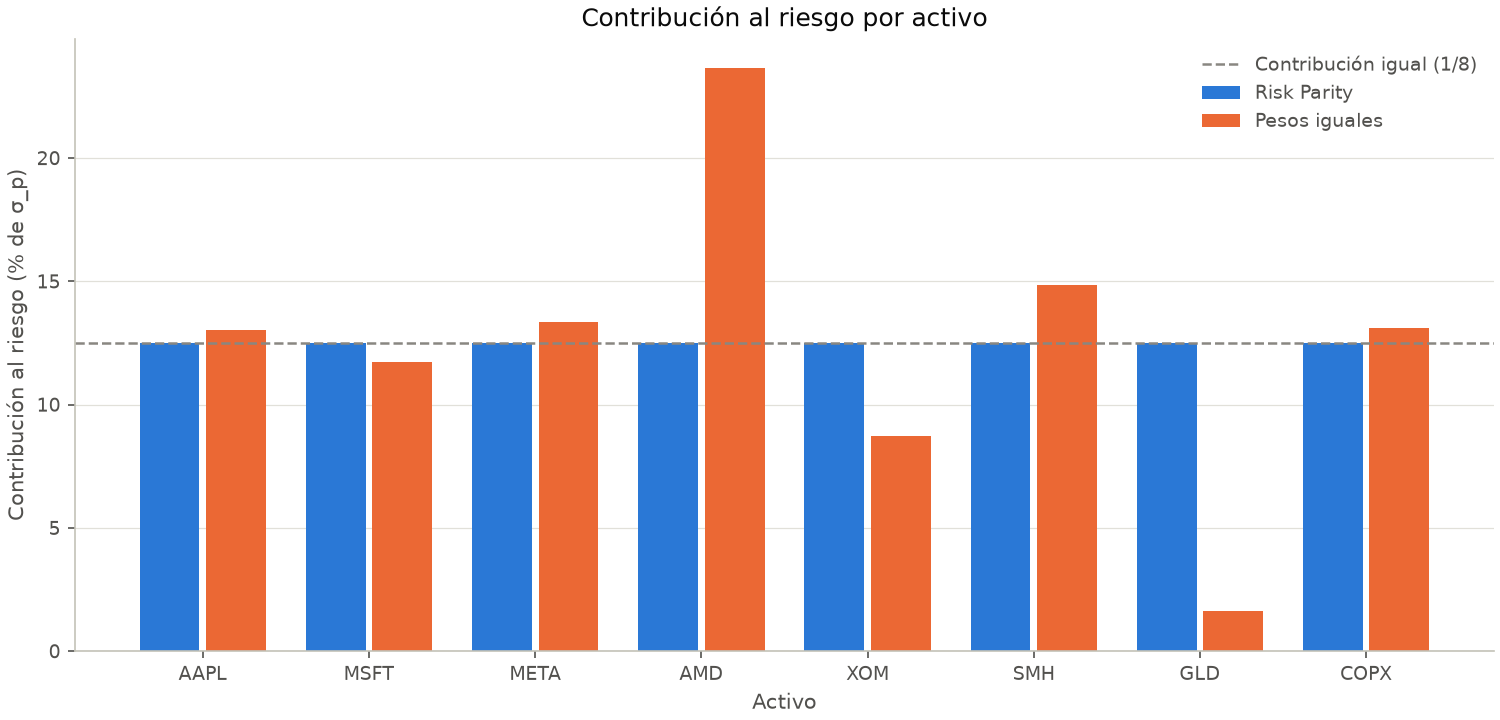

In [36]:
display(Image(filename=FIGURES / "portafolio_contribuciones_riesgo.png"))

**Mejora el Calmar solo en test, pero reduce el riesgo en los tres bloques:**

| Bloque | Calmar RP | Calmar pesos iguales | MDD RP | MDD pesos iguales | Vol RP | Vol pesos iguales |
|---|---|---|---|---|---|---|
| Train | 0.82 | 0.89 | −4.8% | −5.7% | 5.1% | 6.5% |
| Validation | −0.06 | −0.06 | −6.2% | −7.7% | 5.8% | 7.4% |
| Test | 0.07 | 0.01 | −10.7% | −14.8% | 7.2% | 8.8% |

- **Justificación por asignación de riesgo:** con Risk Parity cada activo aporta 12.5% del riesgo
  (dispersión 0). Con pesos iguales AMD aporta 23.7% y GLD 1.6% (dispersión 0.22), y la
  volatilidad ex ante es 22.2% contra 16.6%. Risk Parity también reduce el drawdown entre 16% y 28%
  en cada bloque.
- **El costo:** sobrepondera los activos de baja volatilidad (GLD, XOM) y subpondera AMD y la
  tecnología, que fueron los que más subieron. Por eso sacrifica retorno en train (4.0% contra 5.1%
  anual).

## Pregunta 7. Tres limitaciones para operar con capital real

1. **No hay evidencia de edge fuera de muestra.** La eficiencia del walk-forward es 0.15, y el
   retorno OOS (−0.4% y +0.7% anual) queda por debajo de la tasa libre de riesgo y muy lejos de buy
   & hold (7.8% y 38.4% en los mismos bloques). Lo que gana en train es en buena parte ajuste a la
   muestra.
2. **Sesgos del universo.** Los 8 activos se eligieron en 2026 entre sobrevivientes. Cinco son
   tecnología, y la etiqueta de régimen refleja sobre todo a ese sector. La muestra es casi toda
   alcista: los cortos restaron en los tres bloques (−145k en test contra +187k de los largos).
   Aun así se mantuvieron, para no usar información posterior.
3. **Ejecución modelada de forma optimista.** Llenado completo al Open, al SL y al TP, con slippage
   fijo de 2 bps; borrow fijo de 0.25% sin riesgo de recall ni falta de títulos; sin rechazos ni
   ejecuciones parciales. El impacto de mercado no está en el motor (ver abajo).

### Advertencia obligatoria: ejecución e impacto de mercado

**El backtest asume ejecución completa al precio modelado y no incorpora impacto de mercado ni
fallas de ejecución.** La magnitud del impacto se estima ex post con el modelo de raíz cuadrada:

$$ \text{impacto} \approx \sigma_{diaria} \cdot \sqrt{Q / ADV} $$

con Q el nocional del llenado y ADV y σ de 20 días al cierre de la señal, sobre las operaciones de
test:

In [37]:
impacto = r["impacto_mercado"]["summary"]
display(pd.Series({k: v for k, v in impacto.items() if k != "by_ticker_bps"}))
display(impacto["by_ticker_bps"].rename("bps promedio por llenado"))

block                (2024-01-01 00:00:00, 2026-09-30 00:00:00)
n_trades                                                    224
mean_bps                                                 1.5047
median_bps                                               0.8037
p95_bps                                                  6.6616
max_participation                                        0.0050
impact_cost                                          6,584.5390
impact_pct_equity                                        0.0058
block_return                                             0.0256
impact_pct_return                                        0.2275
dtype: object

ticker
AAPL   0.4966
AMD    0.7927
COPX   6.8097
GLD    0.8900
META   0.6362
MSFT   0.4790
SMH    1.1235
XOM    1.3827
Name: bps promedio por llenado, dtype: float64

- **Por llenado:** 1.5 bps promedio (mediana 0.8, p95 6.7), con participación máxima de 0.5% del
  volumen diario.
- **COPX concentra el impacto:** 6.8 bps promedio, contra menos de 1.4 bps en el resto.
- **En conjunto:** 0.58% del equity inicial de test, cerca de **23% del retorno del bloque** (2.6%
  acumulado). Con márgenes tan delgados, el impacto basta para borrar buena parte de la ganancia.

Con 1 millón de USD el impacto es menor que los costos explícitos (29 bps de ida y vuelta), pero
crece con √Q: con 100 veces más capital sería unas 10 veces mayor, y la estrategia perdería dinero.

# 6. Conclusiones

- **El sistema es metodológicamente sólido:** señales y régimen causales, con pruebas de
  truncamiento; motor verificado con golden tests calculados a mano; walk-forward con purga y
  embargo; decisiones de validation con reglas fijadas antes de verla; y test corrido una sola vez
  con el código congelado.
- **La estrategia no tiene ventaja fuera de muestra.** Es casi plana en validation y test, con
  Sharpe negativo frente al T-Bill y muy por debajo de buy & hold, incluso a igual volatilidad.
- **Lo que sí se sostiene:**
  - la regla 2 de 3, que reduce operaciones y mejora el Calmar frente a cada indicador solo;
  - la capa de régimen: θ por régimen le gana al θ único en los tres bloques, y reversión pierde de
    forma consistente;
  - Risk Parity, que iguala las contribuciones al riesgo y reduce drawdown y volatilidad.
- **Lo que no se sostiene:** el edge in-sample. Optimizar 3 parámetros por régimen con 6 meses de
  datos sobreajusta (eficiencia de 0.15), y con márgenes tan delgados los costos y el impacto de
  mercado deciden el resultado.
- **Para mejorar sin hacer data snooping:** un universo más amplio y diverso, ventanas de
  entrenamiento más largas, un objetivo menos ruidoso que el Calmar de 6 meses y un multiplicador de
  reversión fijado de antemano en un valor más bajo. Todo eso se tendría que validar con datos
  nuevos.

## Uso de inteligencia artificial

Se usó Claude Code (Anthropic) y ChatGPT como asistentes de programación y revisión; el detalle por
integrante está en el README. Las decisiones de diseño de la estrategia, los umbrales y las reglas
de elección las tomó el equipo con evidencia de train. Las reglas de las decisiones de validation
se fijaron y registraron en git antes de ver sus resultados. Todo el código se probó con pytest
antes de integrarse.

# Anexo

## A. Corrida base sobre train (P1, tarea 4)

θ base del SPEC, régimen ignorado: cada activo solo y el portafolio de pesos iguales.

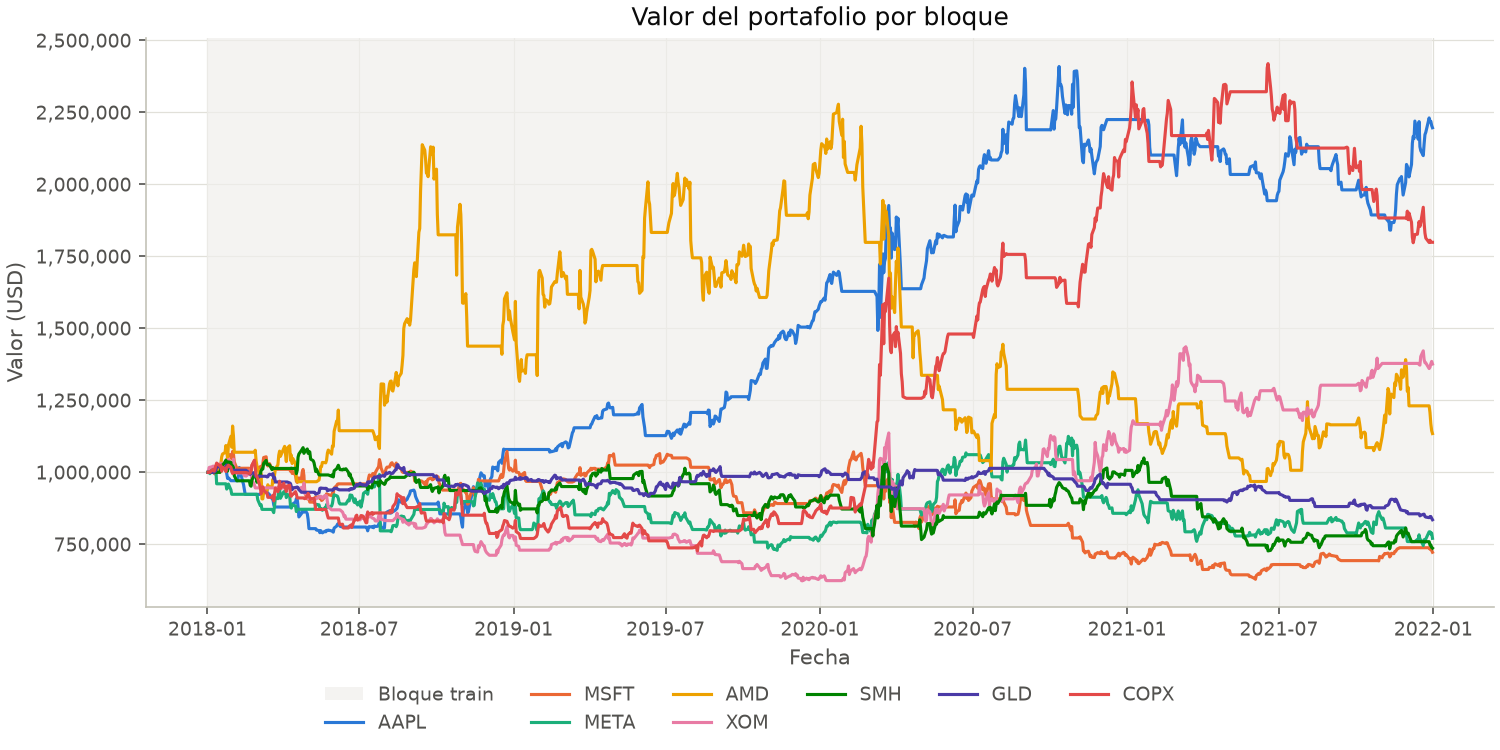

In [38]:
display(Image(filename=FIGURES / "base_equity_activos.png"))

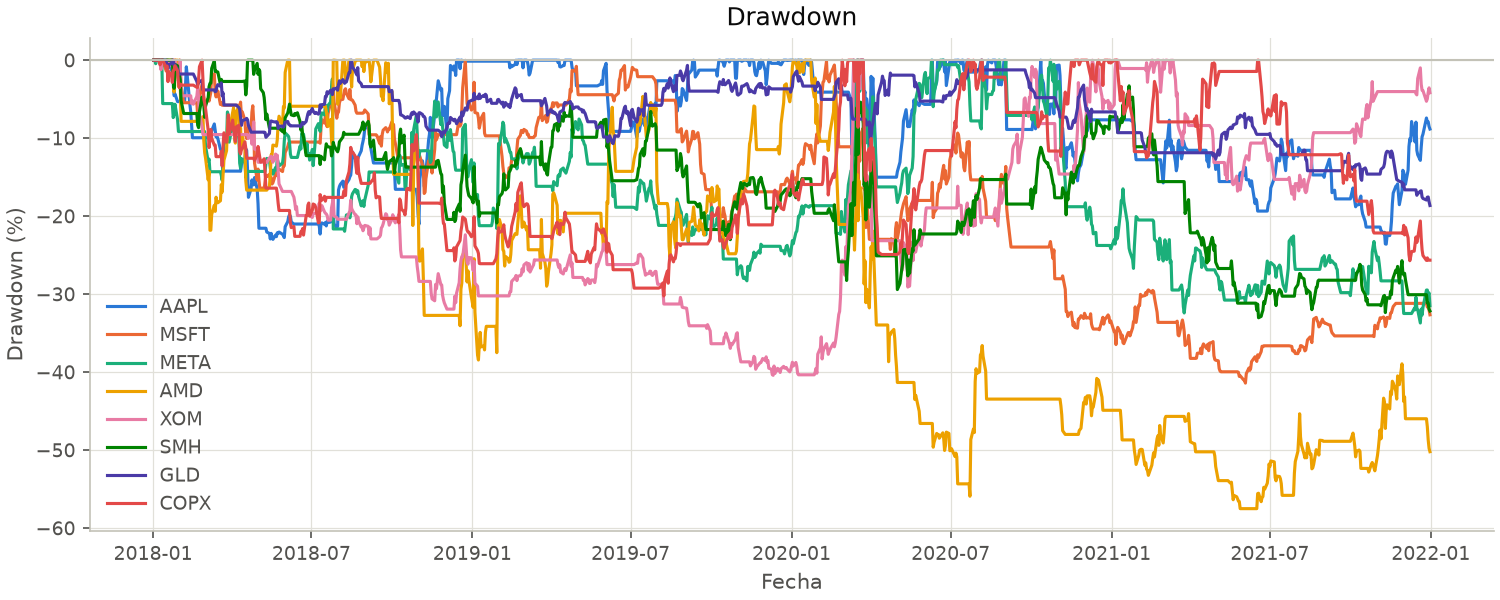

In [39]:
display(Image(filename=FIGURES / "base_drawdown_activos.png"))

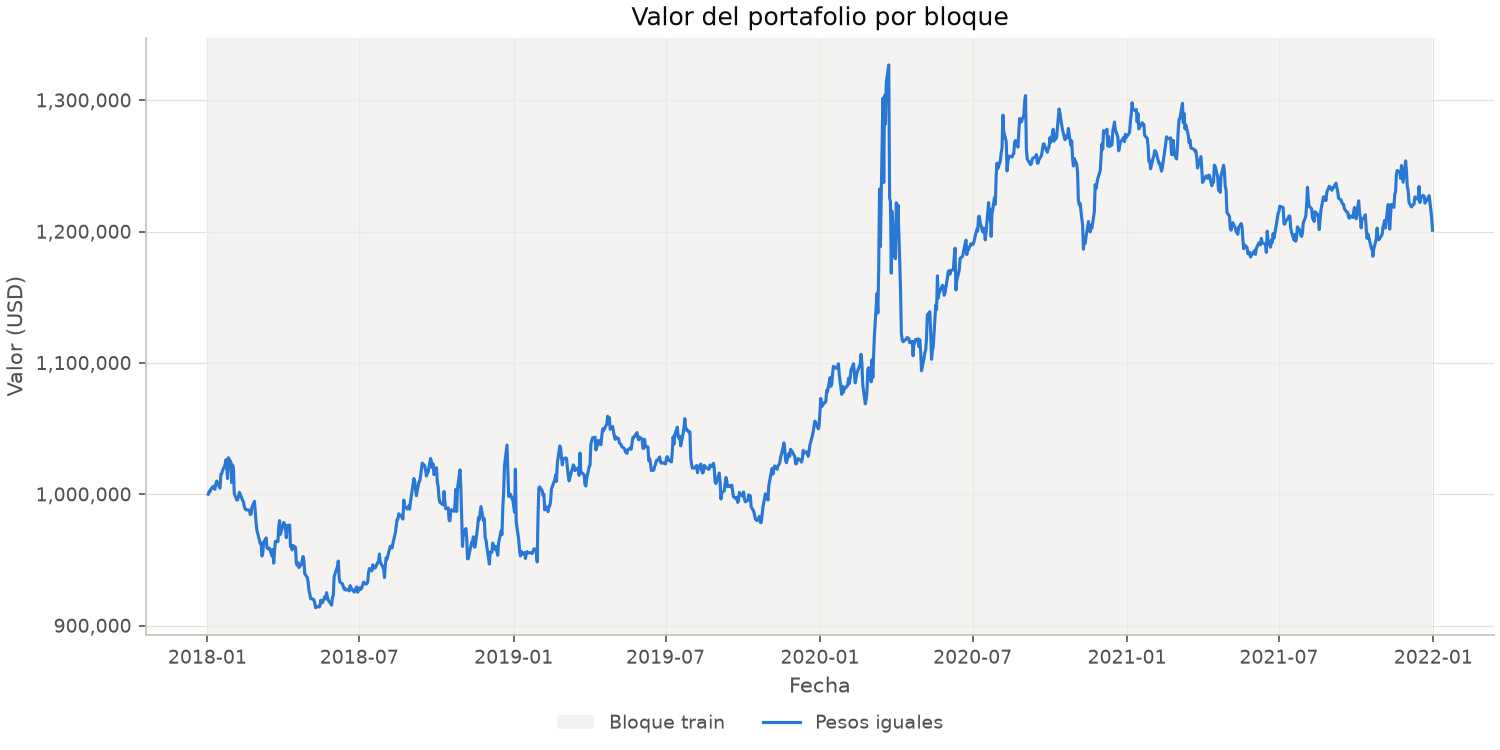

In [40]:
display(Image(filename=FIGURES / "base_equity_pesos_iguales.png"))

## B. Portafolio con θ base en train (P4)

In [41]:
display(r["portafolio"]["weight_stability"])
display(r["portafolio"]["performance"]["train"][["ann_return", "ann_vol", "sharpe", "calmar", "max_drawdown", "n_trades"]])

,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,mean_std,n_reviews
sample,0.0192,0.0223,0.0151,0.0172,0.0297,0.0123,0.0908,0.0131,0.0275,48
ewma,0.0204,0.0225,0.0154,0.0176,0.0277,0.0125,0.0905,0.0125,0.0274,48
ledoit_wolf,0.0178,0.0191,0.0113,0.0163,0.0266,0.0111,0.0706,0.0114,0.0230,48


,ann_return,ann_vol,sharpe,calmar,max_drawdown,n_trades
risk_parity,0.0059,0.0493,-0.0750,0.0725,-0.0816,375
equal,0.0161,0.0653,0.1109,0.1623,-0.0990,375
AAPL,0.2174,0.2422,0.8885,0.9217,-0.2359,45
MSFT,-0.0781,0.1975,-0.3663,-0.1885,-0.4141,47
META,-0.0630,0.2849,-0.1219,-0.1869,-0.3370,47
AMD,0.0321,0.4068,0.2516,0.0558,-0.5750,56
XOM,0.0831,0.2423,0.4054,0.2057,-0.4041,45
SMH,-0.0736,0.2329,-0.2588,-0.2228,-0.3303,43
GLD,-0.0440,0.0865,-0.6013,-0.2359,-0.1864,48
COPX,0.1581,0.2570,0.6554,0.5231,-0.3023,49


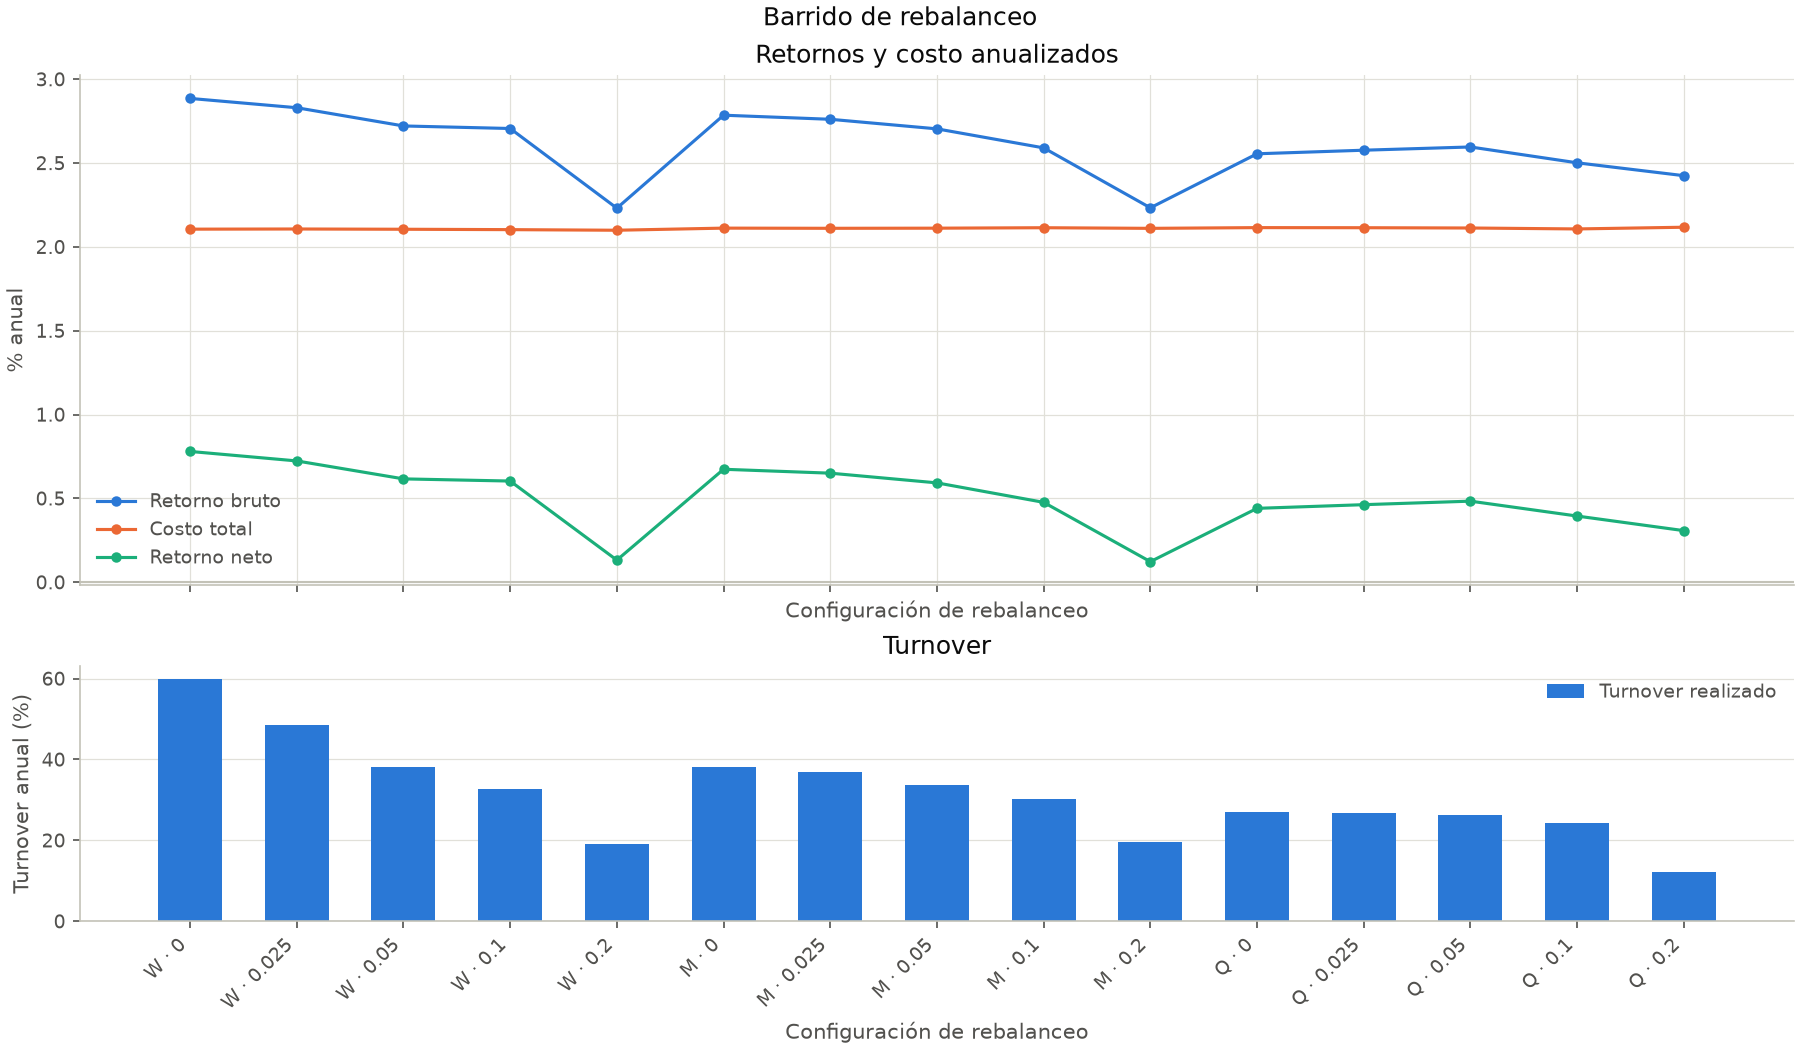

In [42]:
display(Image(filename=FIGURES / "portafolio_barrido_rebalanceo.png"))

## C. Auditoría de sesgos (P1, tarea 5)

In [43]:
display(Markdown((RESULTS / "auditoria_sesgos.md").read_text(encoding="utf-8")))

# Auditoría de sesgos

| Sesgo | Evidencia |
|---|---|
| Look-ahead | La señal de t se ejecuta al Open de t+1 y ese desplazamiento solo existe en `run_backtest`. Pruebas de truncamiento en verde para indicadores y señales (`test_signals.py`), régimen (`test_regimes.py`), pesos (`test_portfolio.py`) y el pipeline completo (`test_pipeline.py`); golden test 9 (t → t+1). El régimen operado es la etiqueta filtrada (forward); Viterbi solo aparece en una figura. |
| Survivorship | Los 8 activos se eligieron en 2026 entre empresas y ETFs que sobrevivieron hasta hoy, así que el resultado está sesgado al alza. Datos completos y traslapados: 2,449 días comunes de 2017-01-03 a 2026-09-30, 0 fechas descartadas y 0 incidencias de calidad. |
| Overfitting / data snooping | Optuna TPE con 150 pruebas por estudio y ventana del walk-forward (131,850 configuraciones evaluadas en total), más 200 random y 200 TPE de diagnóstico. Se elige el medoide del mejor 10% (meseta), no el máximo. m(régimen) no entra al espacio de búsqueda. Eficiencia del walk-forward: rolling por régimen = 0.15, rolling θ único = -0.17, anchored por régimen = -0.14, anchored θ único = -0.07. Test se corre una sola vez con θ congelados. |
| Ejecución optimista | Ejecución al Open de t+1 con slippage de 2 bps en contra en todo llenado, incluidos SL y TP; comisión de 0.125% por lado y borrow en cortos. Empate intrabarra: primero el stop. Gap más allá del TP llena en el TP, sin mejora. Impacto de mercado no modelado; estimado ex post sobre 224 operaciones de test: 1.5 bps promedio por llenado (p95 6.7 bps), 0.58% del equity inicial del bloque. |
| Selección de muestra / periodo | Rango 2017-01-02 → 2026-09-30 y partición train / validation / test fijados en el SPEC antes de ver resultados; 2017 solo calienta indicadores. El walk-forward corre continuo sobre los tres bloques. Validation se usa una vez para decisiones discretas. |
